# Elliptic++ EDA
This notebook explores the heterogeneous Elliptic++ dataset, which contains both transaction nodes and wallet/address nodes.


## 1. Environment and data discovery
Load the libraries, locate the dataset files, and list what is available in the raw folder.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import networkx as nx
from collections import Counter
import os
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('ggplot')
matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['font.size'] = 12

# Paths
DATA_DIR = '../data/raw/elliptic++dataset'
FIG_DIR = '../outputs/figures/elliptic_plus'
os.makedirs(FIG_DIR, exist_ok=True)

# List all files/folders in dataset
for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    sub_indent = '  ' * (level + 1)
    for f in files:
        size_mb = os.path.getsize(os.path.join(root, f)) / (1024**2)
        print(f'{sub_indent}{f} ({size_mb:.2f} MB)')

print("\nSetup complete.")

elliptic++dataset/
  AddrTx_edgelist.csv (20.26 MB)
  txs_edgelist.csv (4.26 MB)
  txs_features.csv (662.60 MB)
  AddrAddr_edgelist.csv (191.34 MB)
  TxAddr_edgelist.csv (35.00 MB)
  wallets_features_classes_combined.csv (580.79 MB)
  txs_classes.csv (2.25 MB)
  wallets_classes.csv (29.01 MB)
  wallets_features.csv (578.37 MB)

Setup complete.


## 2. Transaction layer
Read the transaction feature table, labels, and transaction-to-transaction edges from the original Elliptic graph.


In [2]:
# ── Load Transaction-Level Data ──
# Transaction features (same as original Elliptic)
txs_features_df = pd.read_csv(
    os.path.join(DATA_DIR, 'txs_features.csv'),
    # header=None,
    # dtype={0: np.int64, **{i: np.float32 for i in range(1, 167)}}
)

txs_classes_df = pd.read_csv(os.path.join(DATA_DIR, 'txs_classes.csv'))
txs_edgelist_df = pd.read_csv(os.path.join(DATA_DIR, 'txs_edgelist.csv'))

# Rename columns
num_agg = 72
num_local = txs_features_df.shape[1] - 2 - num_agg
txs_features_df.columns = ['txId', 'time_step'] + \
    [f'local_feat_{i}' for i in range(num_local)] + \
    [f'agg_feat_{i}' for i in range(num_agg)]

print(f"Transaction features shape: {txs_features_df.shape}")
print(f"Transaction classes shape:  {txs_classes_df.shape}")
print(f"Transaction edgelist shape: {txs_edgelist_df.shape}")

Transaction features shape: (203769, 184)
Transaction classes shape:  (203769, 2)
Transaction edgelist shape: (234355, 2)


## 3. Wallet and address layer
Load the wallet features, wallet labels, and the additional edge lists that make Elliptic++ heterogeneous.


In [14]:
# ── Load Actor & Address Data ──
# Auto-detect file paths
import glob

def find_file(pattern):
    """Search for a file matching the pattern in DATA_DIR."""
    matches = glob.glob(os.path.join(DATA_DIR, '**', pattern), recursive=True)
    if matches:
        print(f"  Found: {matches[0]}")
        return matches[0]
    else:
        print(f"  [WARN] Not found: {pattern}")
        return None

print("Searching for dataset files...")

# Actor/Wallet files
actor_features_path = find_file('*wallets_features.csv*') or find_file('*actor*feature*')
actor_classes_path = find_file('*wallets_classes*')
actor_edgelist_path = find_file('*wallet*edge*') or find_file('*actor*edge*') or find_file('*AddrAddr*')

# Address mapping files
addr_tx_path = find_file('*address*tx*') or find_file('*Addr*Tx*') or find_file('*address*transaction*')
tx_addr_path = find_file('*TxAddr*edge*') or find_file('*addr*wallet*') or find_file('*address*actor*')

# Load whatever was found
actor_features_df = pd.read_csv(actor_features_path) if actor_features_path else None
actor_classes_df = pd.read_csv(actor_classes_path) if actor_classes_path else None
actor_edgelist_df = pd.read_csv(actor_edgelist_path) if actor_edgelist_path else None
addr_tx_df = pd.read_csv(addr_tx_path) if addr_tx_path else None
tx_addr_df = pd.read_csv(tx_addr_path) if tx_addr_path else None

# Print shapes
for name, df_obj in [('Actor features', actor_features_df),
                      ('Actor classes', actor_classes_df),
                      ('Actor edgelist', actor_edgelist_df),
                      ('Address-TX map', addr_tx_df),
                      ('TX-Address map', tx_addr_df)]:
    if df_obj is not None:
        print(f"{name:20s} shape: {df_obj.shape}")
    else:
        print(f"{name:20s} — NOT FOUND")

Searching for dataset files...
  Found: ../data/raw/elliptic++dataset/wallets_features.csv
  Found: ../data/raw/elliptic++dataset/wallets_classes.csv
  [WARN] Not found: *wallet*edge*
  [WARN] Not found: *actor*edge*
  Found: ../data/raw/elliptic++dataset/AddrAddr_edgelist.csv
  [WARN] Not found: *address*tx*
  Found: ../data/raw/elliptic++dataset/AddrTx_edgelist.csv
  Found: ../data/raw/elliptic++dataset/TxAddr_edgelist.csv
Actor features       shape: (1268260, 57)
Actor classes        shape: (822942, 2)
Actor edgelist       shape: (2868964, 2)
Address-TX map       shape: (477117, 2)
TX-Address map       shape: (837124, 2)


## 4. Merge transaction labels
Combine transaction features with labels so later plots can compare illicit and licit behavior directly.


In [19]:
# ── Merge transaction data ──
txs_df = txs_features_df.merge(txs_classes_df, on='txId', how='left')
txs_df['class'] = txs_df['class'].map({'1': 'illicit', '2': 'licit', 'unknown': 'unknown'})

# ── Merge actor data ──
# Detect column names
print("Actor features columns:", actor_features_df.columns.tolist()[:10], "...")
print("Actor classes columns:", actor_classes_df.columns.tolist())

# Merge actors
actor_id_col = actor_features_df.columns[0]  # first column is the actor/wallet id
actor_class_col = actor_classes_df.columns[0]

actors_df = actor_features_df.merge(actor_classes_df, left_on=actor_id_col, right_on=actor_class_col, how='left')

print(f"\nMerged transactions: {txs_df.shape}")
print(f"Merged actors:       {actors_df.shape}")

# Check class columns
for col in actors_df.columns:
    if 'class' in col.lower() or 'label' in col.lower():
        print(f"\nActor label column '{col}':")
        print(actors_df[col].value_counts())

Actor features columns: ['address', 'Time step', 'num_txs_as_sender', 'num_txs_as receiver', 'first_block_appeared_in', 'last_block_appeared_in', 'lifetime_in_blocks', 'total_txs', 'first_sent_block', 'first_received_block'] ...
Actor classes columns: ['address', 'class']

Merged transactions: (203769, 185)
Merged actors:       (1268260, 58)

Actor label column 'class':
class
3    900788
2    338871
1     28601
Name: count, dtype: int64


In [22]:
print("Column name:", txs_classes_df.columns.tolist())
print("Unique values:", txs_classes_df.iloc[:, -1].unique()[:20])
print("Dtype:", txs_classes_df.iloc[:, -1].dtype)
print("\nValue counts:")
print(txs_classes_df.iloc[:, -1].value_counts())

Column name: ['txId', 'class']
Unique values: [3 2 1]
Dtype: int64

Value counts:
class
3    157205
2     42019
1      4545
Name: count, dtype: int64


## 5. Sanity checks and schema inspection
Quickly verify column names and look for any unexpected label encodings before plotting.


Classes: {'unknown': 157205, 'licit': 42019, 'illicit': 4545}


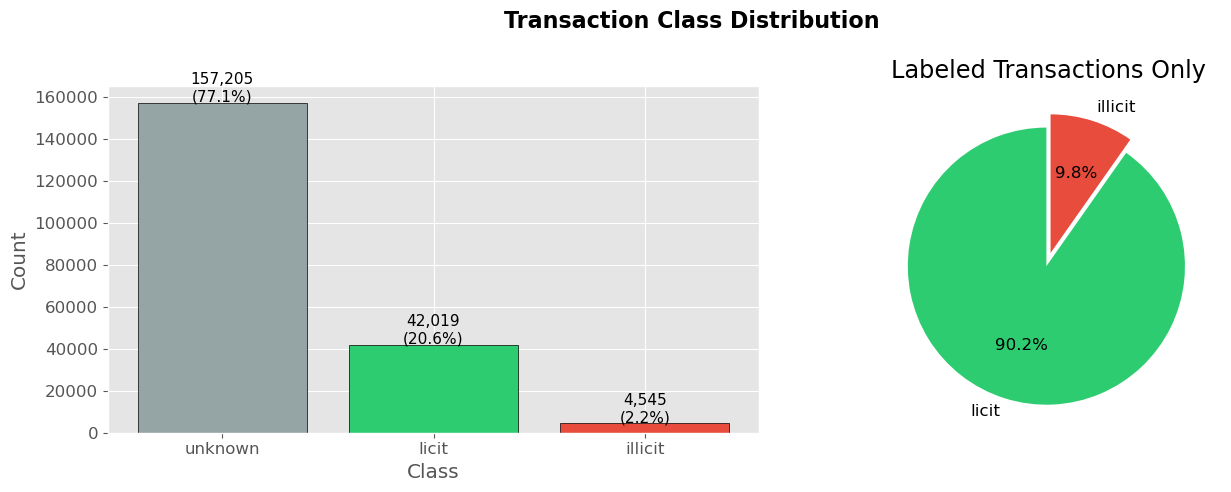

Saved: tx_class_distribution.png


In [23]:
# ══════════════════════════════════════════════════════════
# SECTION 1: TRANSACTION STATISTICS
# ══════════════════════════════════════════════════════════

# Reload classes fresh from CSV to avoid double-mapping
txs_classes_fresh = pd.read_csv(os.path.join(DATA_DIR, 'txs_classes.csv'))
class_col = txs_classes_fresh.columns[-1]
id_col = txs_classes_fresh.columns[0]

# Map: handle both int and string values
txs_classes_fresh['class'] = txs_classes_fresh[class_col].astype(str).str.strip().map(
    {'1': 'illicit', '2': 'licit', 'unknown': 'unknown'}
).fillna('unknown')

# Merge with features
txs_df = txs_features_df.merge(txs_classes_fresh[[id_col, 'class']],
                                left_on=txs_features_df.columns[0],
                                right_on=id_col, how='left')
txs_df['class'] = txs_df['class'].fillna('unknown')

print("Classes:", txs_df['class'].value_counts().to_dict())

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transaction Class Distribution', fontsize=16, fontweight='bold')

class_counts = txs_df['class'].value_counts()
colors = {'illicit': '#e74c3c', 'licit': '#2ecc71', 'unknown': '#95a5a6'}
bar_colors = [colors[c] for c in class_counts.index]

# Bar chart
axes[0].bar(class_counts.index, class_counts.values, color=bar_colors, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, (cls, cnt) in enumerate(class_counts.items()):
    axes[0].text(i, cnt + 500, f'{cnt:,}\n({cnt/len(txs_df)*100:.1f}%)', ha='center', fontsize=11)

# Pie chart (labeled only)
labeled_tx = txs_df[txs_df['class'] != 'unknown']
labeled_counts = labeled_tx['class'].value_counts()
axes[1].pie(labeled_counts, labels=labeled_counts.index,
            colors=[colors[c] for c in labeled_counts.index],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12},
            explode=[0.05] * len(labeled_counts))
axes[1].set_title('Labeled Transactions Only')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'tx_class_distribution.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: tx_class_distribution.png")

## 6. Transaction temporal patterns
Study how transactions are distributed over time and whether illicit activity is concentrated in specific steps.


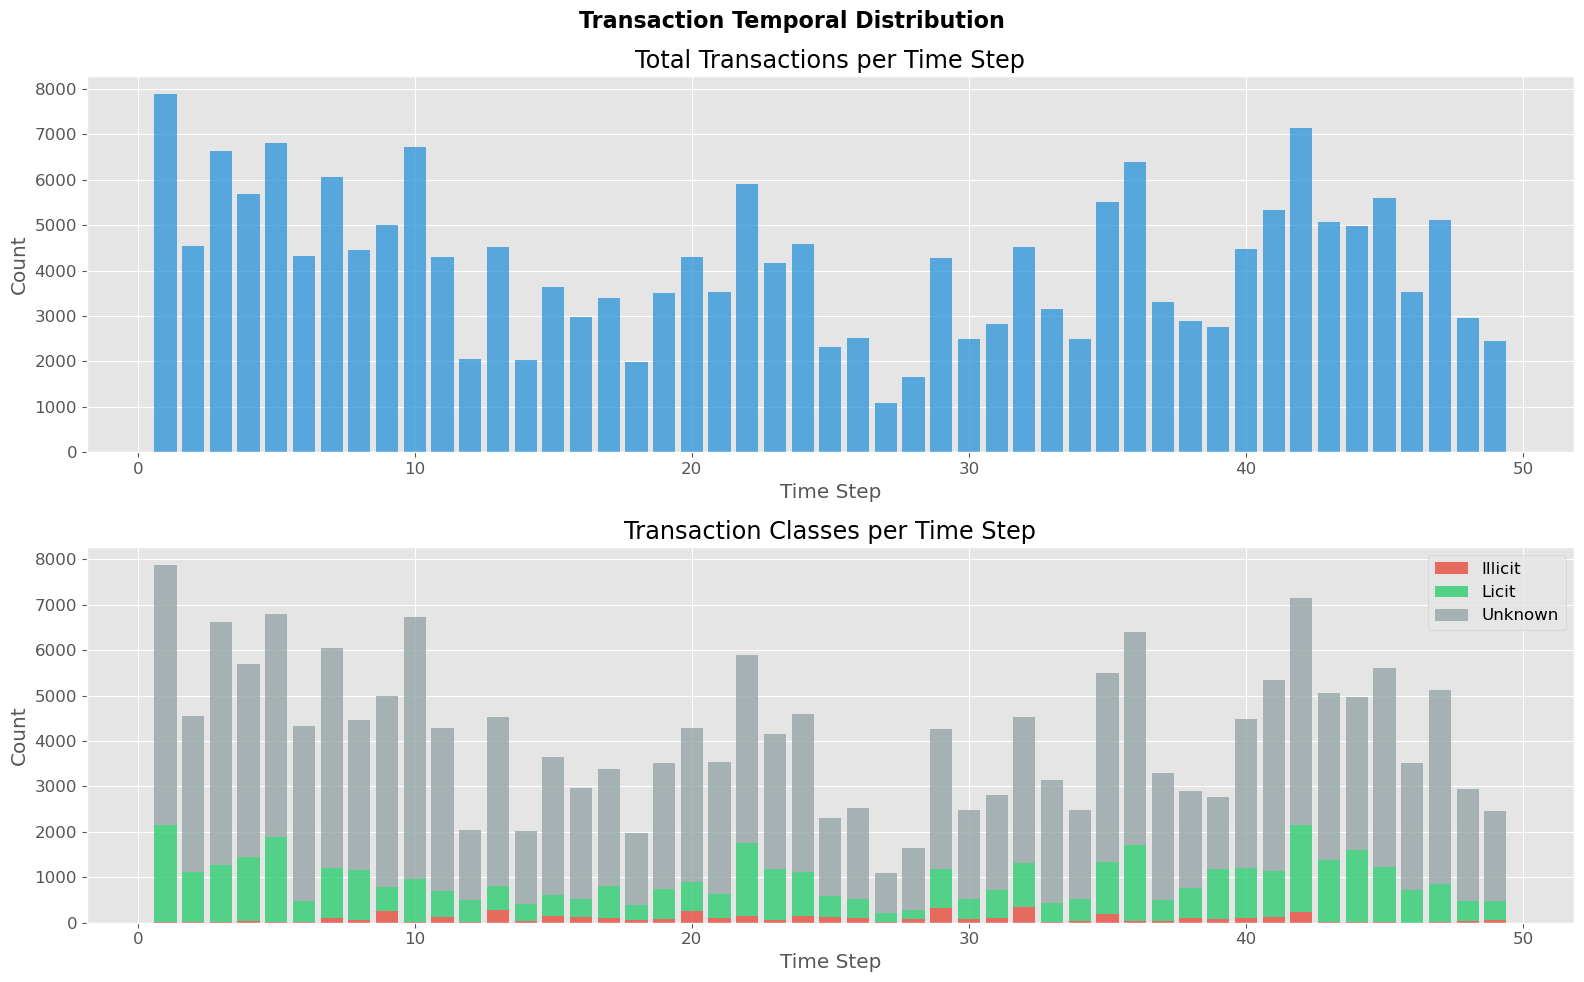

Saved: tx_temporal_distribution.png


In [24]:
# ── Transactions Over Time Steps ──
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Transaction Temporal Distribution', fontsize=16, fontweight='bold')

all_steps = range(1, int(txs_df['time_step'].max()) + 1)

# Total per step
tx_per_step = txs_df.groupby('time_step').size()
axes[0].bar(tx_per_step.index, tx_per_step.values, color='#3498db', alpha=0.8, edgecolor='none')
axes[0].set_title('Total Transactions per Time Step')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Count')

# Stacked by class
illicit_per_step = txs_df[txs_df['class'] == 'illicit'].groupby('time_step').size()
licit_per_step = txs_df[txs_df['class'] == 'licit'].groupby('time_step').size()
unknown_per_step = txs_df[txs_df['class'] == 'unknown'].groupby('time_step').size()

axes[1].bar(all_steps, [illicit_per_step.get(s, 0) for s in all_steps],
            label='Illicit', color='#e74c3c', alpha=0.8)
axes[1].bar(all_steps, [licit_per_step.get(s, 0) for s in all_steps],
            bottom=[illicit_per_step.get(s, 0) for s in all_steps],
            label='Licit', color='#2ecc71', alpha=0.8)
axes[1].bar(all_steps, [unknown_per_step.get(s, 0) for s in all_steps],
            bottom=[illicit_per_step.get(s, 0) + licit_per_step.get(s, 0) for s in all_steps],
            label='Unknown', color='#95a5a6', alpha=0.8)
axes[1].set_title('Transaction Classes per Time Step')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'tx_temporal_distribution.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: tx_temporal_distribution.png")

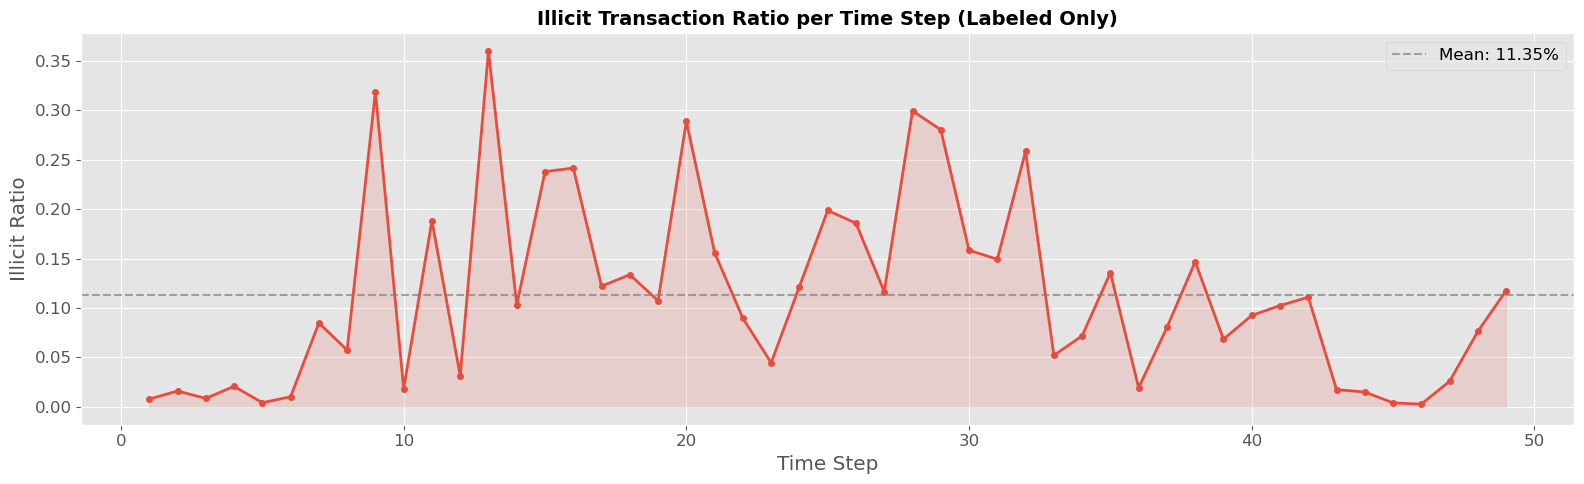

Saved: tx_illicit_ratio.png


In [25]:
# ── Illicit Ratio Over Time ──
fig, ax = plt.subplots(figsize=(16, 5))

illicit_ratio = []
for s in all_steps:
    step_df = txs_df[(txs_df['time_step'] == s) & (txs_df['class'] != 'unknown')]
    ratio = len(step_df[step_df['class'] == 'illicit']) / len(step_df) if len(step_df) > 0 else 0
    illicit_ratio.append(ratio)

ax.plot(all_steps, illicit_ratio, color='#e74c3c', linewidth=2, marker='o', markersize=4)
ax.axhline(y=np.mean(illicit_ratio), color='gray', linestyle='--', alpha=0.7,
           label=f'Mean: {np.mean(illicit_ratio):.2%}')
ax.fill_between(all_steps, illicit_ratio, alpha=0.15, color='#e74c3c')
ax.set_title('Illicit Transaction Ratio per Time Step (Labeled Only)', fontsize=14, fontweight='bold')
ax.set_xlabel('Time Step')
ax.set_ylabel('Illicit Ratio')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'tx_illicit_ratio.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: tx_illicit_ratio.png")

## 7. Transaction graph diagnostics
Inspect degree distribution, class-specific degree behavior, and a representative transaction subgraph.


In [26]:
# ══════════════════════════════════════════════════════════
# SECTION 2: TRANSACTION GRAPH
# ══════════════════════════════════════════════════════════

print("Building transaction graph...")
tx_edge_cols = txs_edgelist_df.columns.tolist()
txG = nx.from_pandas_edgelist(txs_edgelist_df, source=tx_edge_cols[0], target=tx_edge_cols[1],
                               create_using=nx.DiGraph())

print(f"Nodes: {txG.number_of_nodes():,}")
print(f"Edges: {txG.number_of_edges():,}")
print(f"Avg in-degree:  {np.mean([d for _, d in txG.in_degree()]):.2f}")
print(f"Avg out-degree: {np.mean([d for _, d in txG.out_degree()]):.2f}")
print(f"Density: {nx.density(txG):.6f}")

num_wcc = nx.number_weakly_connected_components(txG)
largest_wcc = max(nx.weakly_connected_components(txG), key=len)
print(f"Weakly connected components: {num_wcc:,}")
print(f"Largest component: {len(largest_wcc):,} nodes ({len(largest_wcc)/txG.number_of_nodes()*100:.1f}%)")

Building transaction graph...
Nodes: 203,769
Edges: 234,355
Avg in-degree:  1.15
Avg out-degree: 1.15
Density: 0.000006
Weakly connected components: 49
Largest component: 7,880 nodes (3.9%)


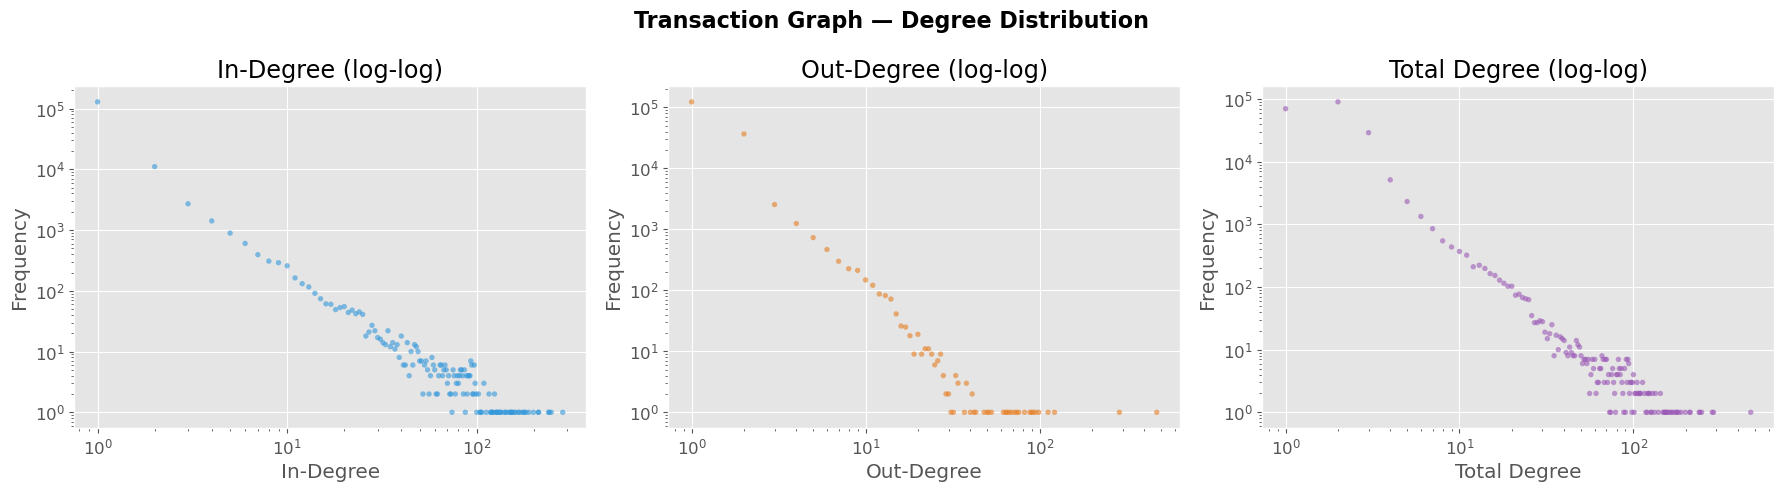

Saved: tx_degree_distribution.png


In [27]:
# ── Transaction Degree Distribution (log-log) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Transaction Graph — Degree Distribution', fontsize=16, fontweight='bold')

in_deg = [d for _, d in txG.in_degree()]
out_deg = [d for _, d in txG.out_degree()]
total_deg = [d for _, d in txG.degree()]

for ax, degrees, title, color in zip(
    axes, [in_deg, out_deg, total_deg],
    ['In-Degree', 'Out-Degree', 'Total Degree'],
    ['#3498db', '#e67e22', '#9b59b6']
):
    deg_counts = Counter(degrees)
    vals = sorted(deg_counts.keys())
    freqs = [deg_counts[d] for d in vals]
    ax.scatter(vals, freqs, c=color, alpha=0.6, s=15, edgecolors='none')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'{title} (log-log)')
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'tx_degree_distribution.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: tx_degree_distribution.png")

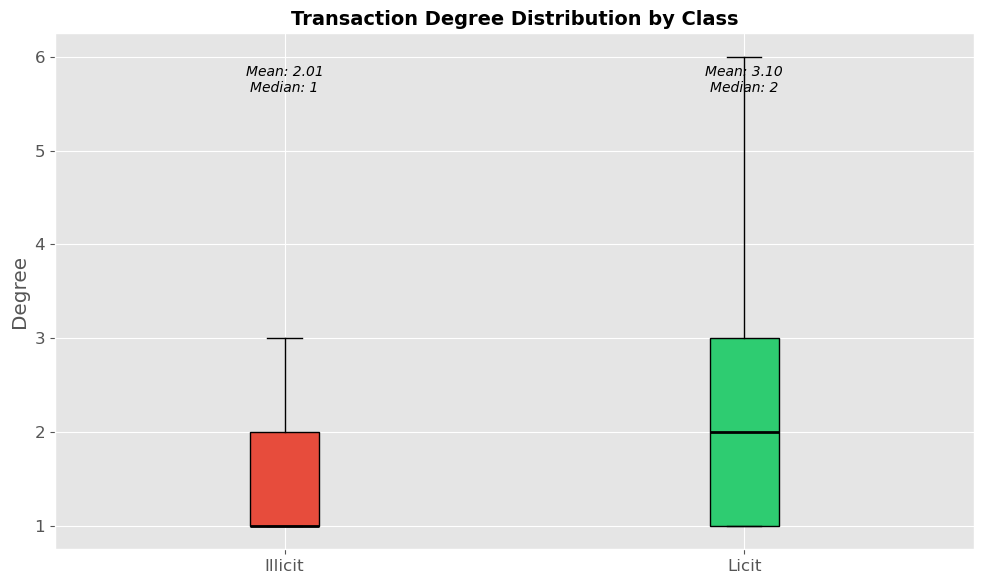

Saved: tx_degree_by_class.png


In [28]:
# ── Transaction Degree by Class ──
tx_class_map = dict(zip(txs_df['txId'], txs_df['class']))
tx_deg_dict = dict(txG.degree())

deg_by_class = {'illicit': [], 'licit': []}
for node, deg in tx_deg_dict.items():
    cls = tx_class_map.get(node, 'unknown')
    if cls in deg_by_class:
        deg_by_class[cls].append(deg)

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot([deg_by_class['illicit'], deg_by_class['licit']],
                labels=['Illicit', 'Licit'], patch_artist=True, showfliers=False,
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][1].set_facecolor('#2ecc71')

ax.set_title('Transaction Degree Distribution by Class', fontsize=14, fontweight='bold')
ax.set_ylabel('Degree')

for i, cls in enumerate(['illicit', 'licit']):
    mean_val = np.mean(deg_by_class[cls])
    median_val = np.median(deg_by_class[cls])
    ax.text(i + 1, ax.get_ylim()[1] * 0.9,
            f'Mean: {mean_val:.2f}\nMedian: {median_val:.0f}',
            ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'tx_degree_by_class.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: tx_degree_by_class.png")

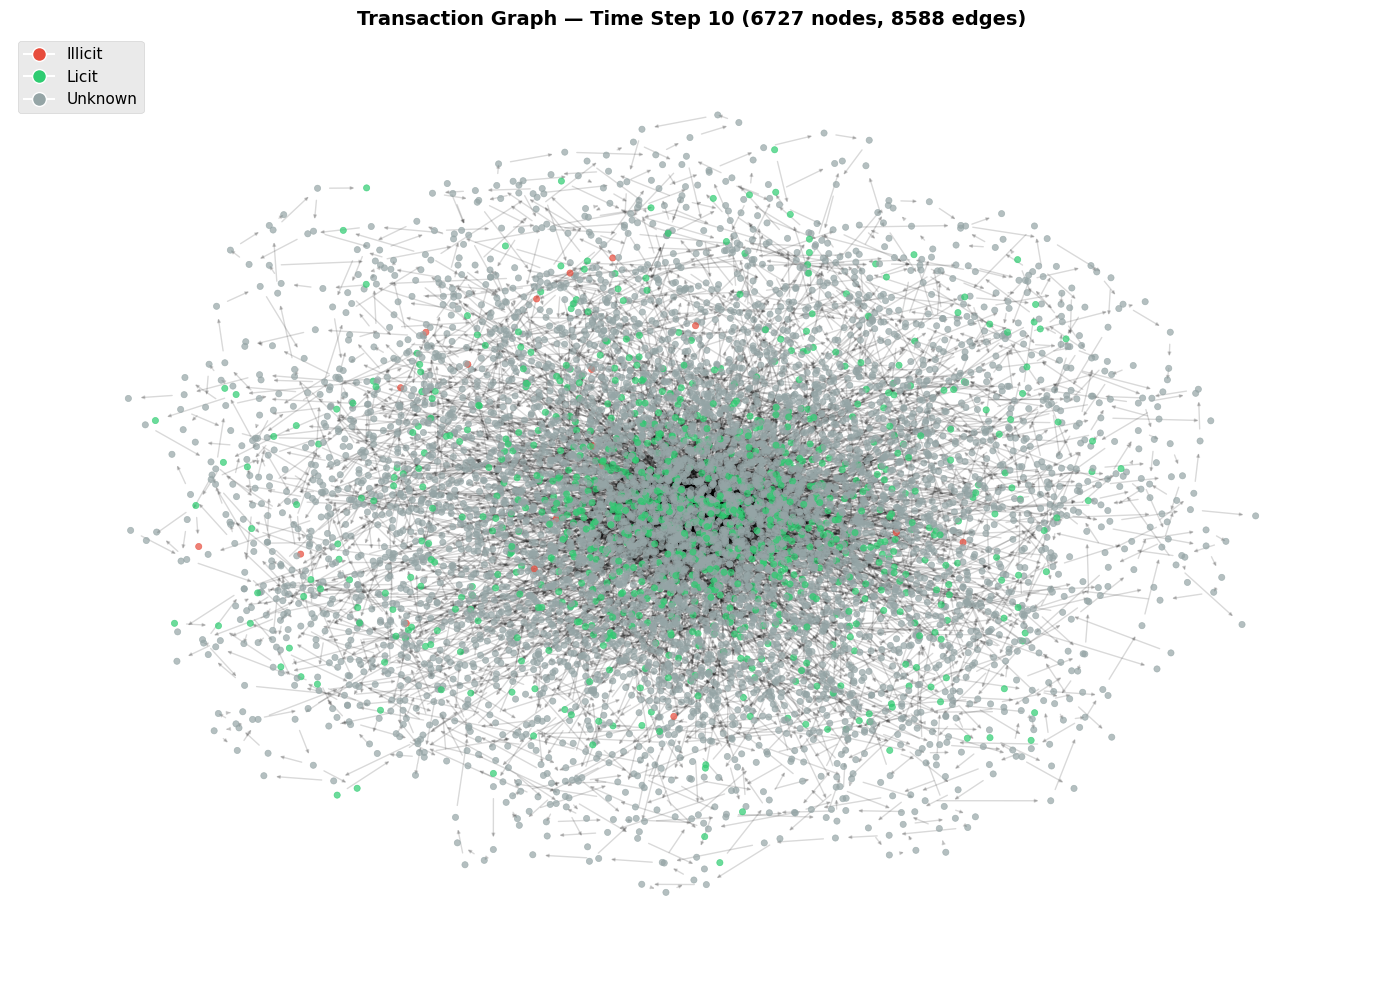

Saved: tx_subgraph.png


In [29]:
# ── Transaction Subgraph (single time step) ──
sample_step = 10
step_nodes = set(txs_df[txs_df['time_step'] == sample_step]['txId'].values)
sub_txG = txG.subgraph([n for n in txG.nodes() if n in step_nodes]).copy()

node_colors = []
for n in sub_txG.nodes():
    cls = tx_class_map.get(n, 'unknown')
    node_colors.append({'illicit': '#e74c3c', 'licit': '#2ecc71', 'unknown': '#95a5a6'}.get(cls, '#95a5a6'))

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(sub_txG, seed=42, k=0.5)
nx.draw_networkx_edges(sub_txG, pos, alpha=0.15, arrows=True, arrowsize=5, ax=ax)
nx.draw_networkx_nodes(sub_txG, pos, node_color=node_colors, node_size=20, alpha=0.7, ax=ax)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Illicit'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=10, label='Licit'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#95a5a6', markersize=10, label='Unknown'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)
ax.set_title(f'Transaction Graph — Time Step {sample_step} ({sub_txG.number_of_nodes()} nodes, {sub_txG.number_of_edges()} edges)',
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'tx_subgraph.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: tx_subgraph.png")

## 8. Feature analysis caveats
Some feature plots can be noisy because the dataset is high-dimensional and strongly imbalanced.
These diagnostics help spot redundancy, leakage, or unusually separable features before modeling.


## Possible issues in feature distribution analysis
some features have the issue that most values are the same but large discrimination happens for several outliers, here are possible ways to avoid it:
1. Filters out features where both classes have zero standard deviation
2. Filters out features where >90% of values are the same (e.g., all zeros with a few outliers)
3. Uses shared np.linspace bins so both histograms align on the same x-axis range
4. Only selects features that will actually produce visible, meaningful histograms

## 9. Transaction feature correlations
Look for correlated transaction features and see whether any groups stand out as especially informative.


Selected 9 features from 107 valid features
Top features: ['local_feat_52', 'local_feat_54', 'local_feat_89', 'local_feat_88', 'local_feat_53', 'local_feat_51', 'local_feat_90', 'local_feat_58', 'local_feat_64']


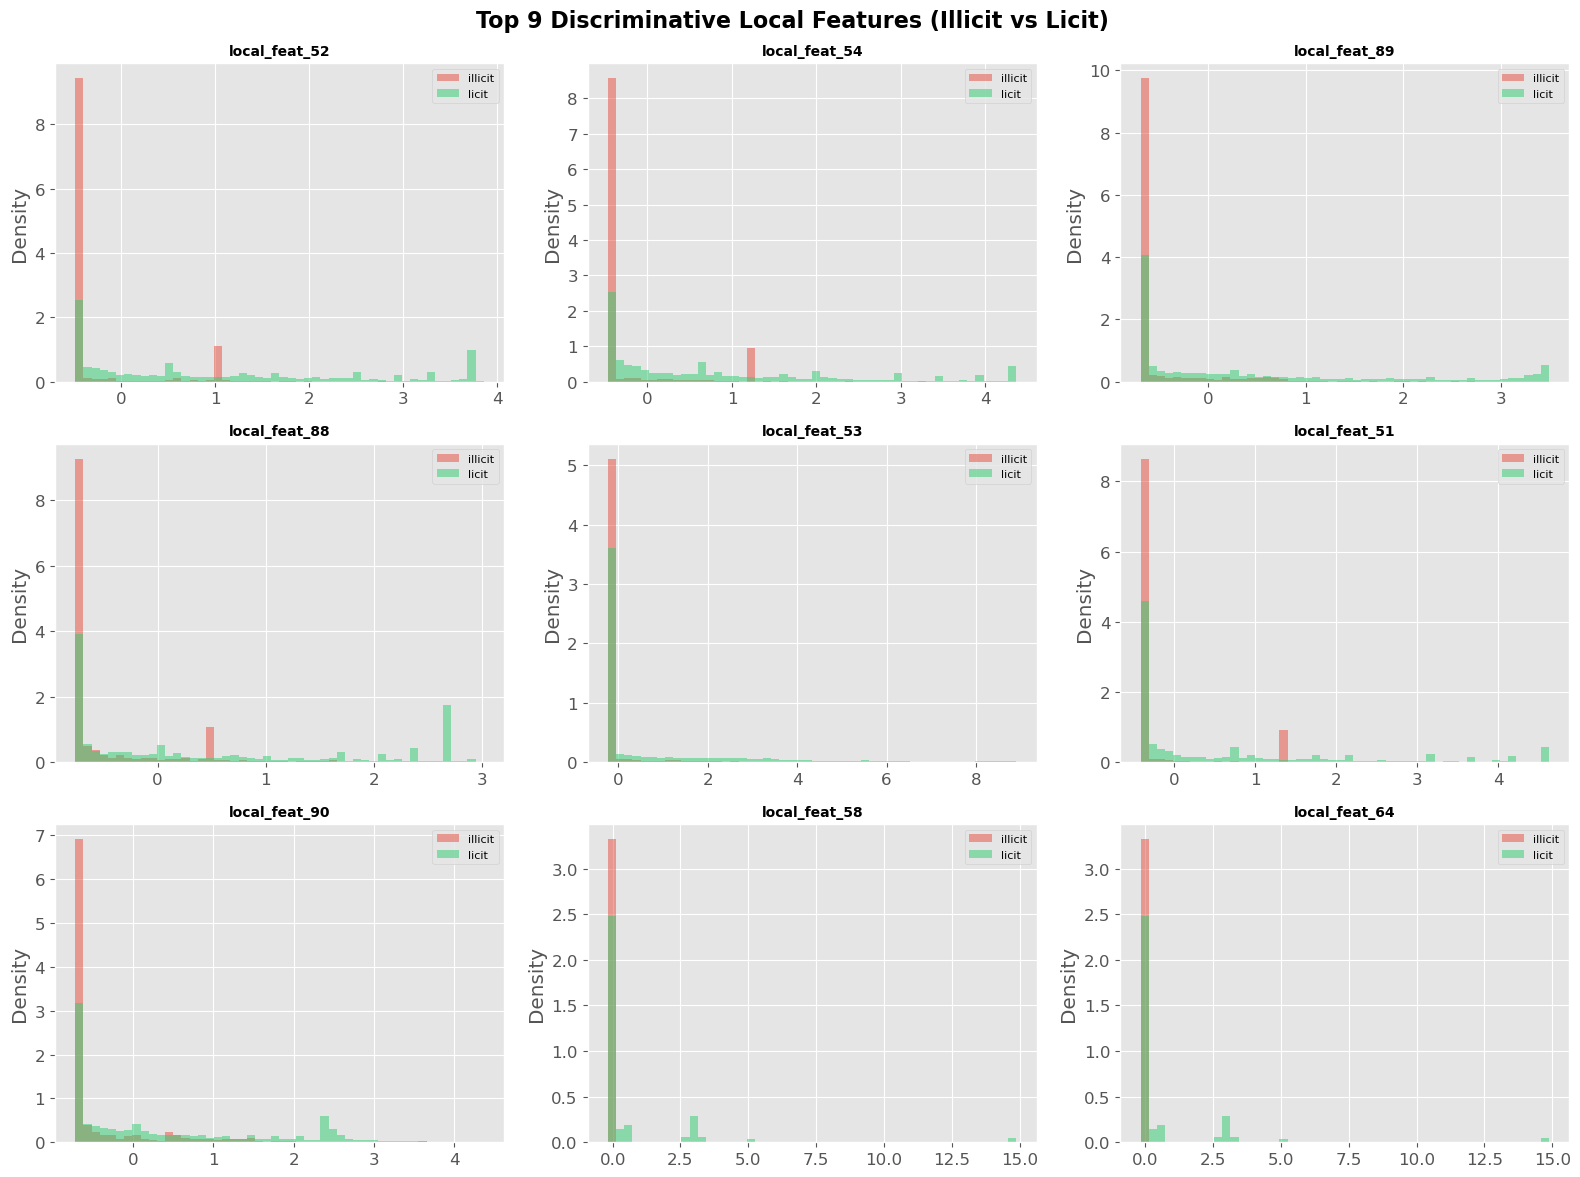

Saved: tx_local_feature_distributions.png


In [51]:
# ══════════════════════════════════════════════════════════
# SECTION 3: TRANSACTION FEATURE ANALYSIS
# ══════════════════════════════════════════════════════════

local_feat_cols = [c for c in txs_df.columns if c.startswith('local_feat_')]
labeled_tx = txs_df[txs_df['class'].isin(['illicit', 'licit'])]

# Find discriminative features, but SKIP features with no variance
feat_diffs = []
for col in local_feat_cols:
    illicit_data = labeled_tx[labeled_tx['class'] == 'illicit'][col].dropna()
    licit_data = labeled_tx[labeled_tx['class'] == 'licit'][col].dropna()
    
    # Skip if either class has zero variance or all same values
    if illicit_data.std() == 0 and licit_data.std() == 0:
        continue
    # Skip if >90% of values are the same (e.g., all zeros)
    all_data = labeled_tx[col].dropna()
    most_common_pct = all_data.value_counts(normalize=True).iloc[0]
    if most_common_pct > 0.90:
        continue
    
    diff = abs(illicit_data.mean() - licit_data.mean())
    feat_diffs.append((col, diff))

feat_diffs.sort(key=lambda x: x[1], reverse=True)
top_features = [f[0] for f in feat_diffs[:9]]
print(f"Selected {len(top_features)} features from {len(feat_diffs)} valid features")
print("Top features:", top_features)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Top 9 Discriminative Local Features (Illicit vs Licit)', fontsize=16, fontweight='bold')

for ax, feat in zip(axes.flat, top_features):
    all_data = labeled_tx[feat].dropna()
    lower = all_data.quantile(0.01)
    upper = all_data.quantile(0.99)
    
    # Use shared bins for both classes
    bins = np.linspace(lower, upper, 51)
    
    for cls, color in [('illicit', '#e74c3c'), ('licit', '#2ecc71')]:
        data = labeled_tx[labeled_tx['class'] == cls][feat].dropna()
        data_clipped = data[(data >= lower) & (data <= upper)]
        if len(data_clipped) > 0:
            ax.hist(data_clipped, bins=bins, alpha=0.5, color=color, label=cls, density=True)
    
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'tx_local_feature_distributions.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: tx_local_feature_distributions.png")

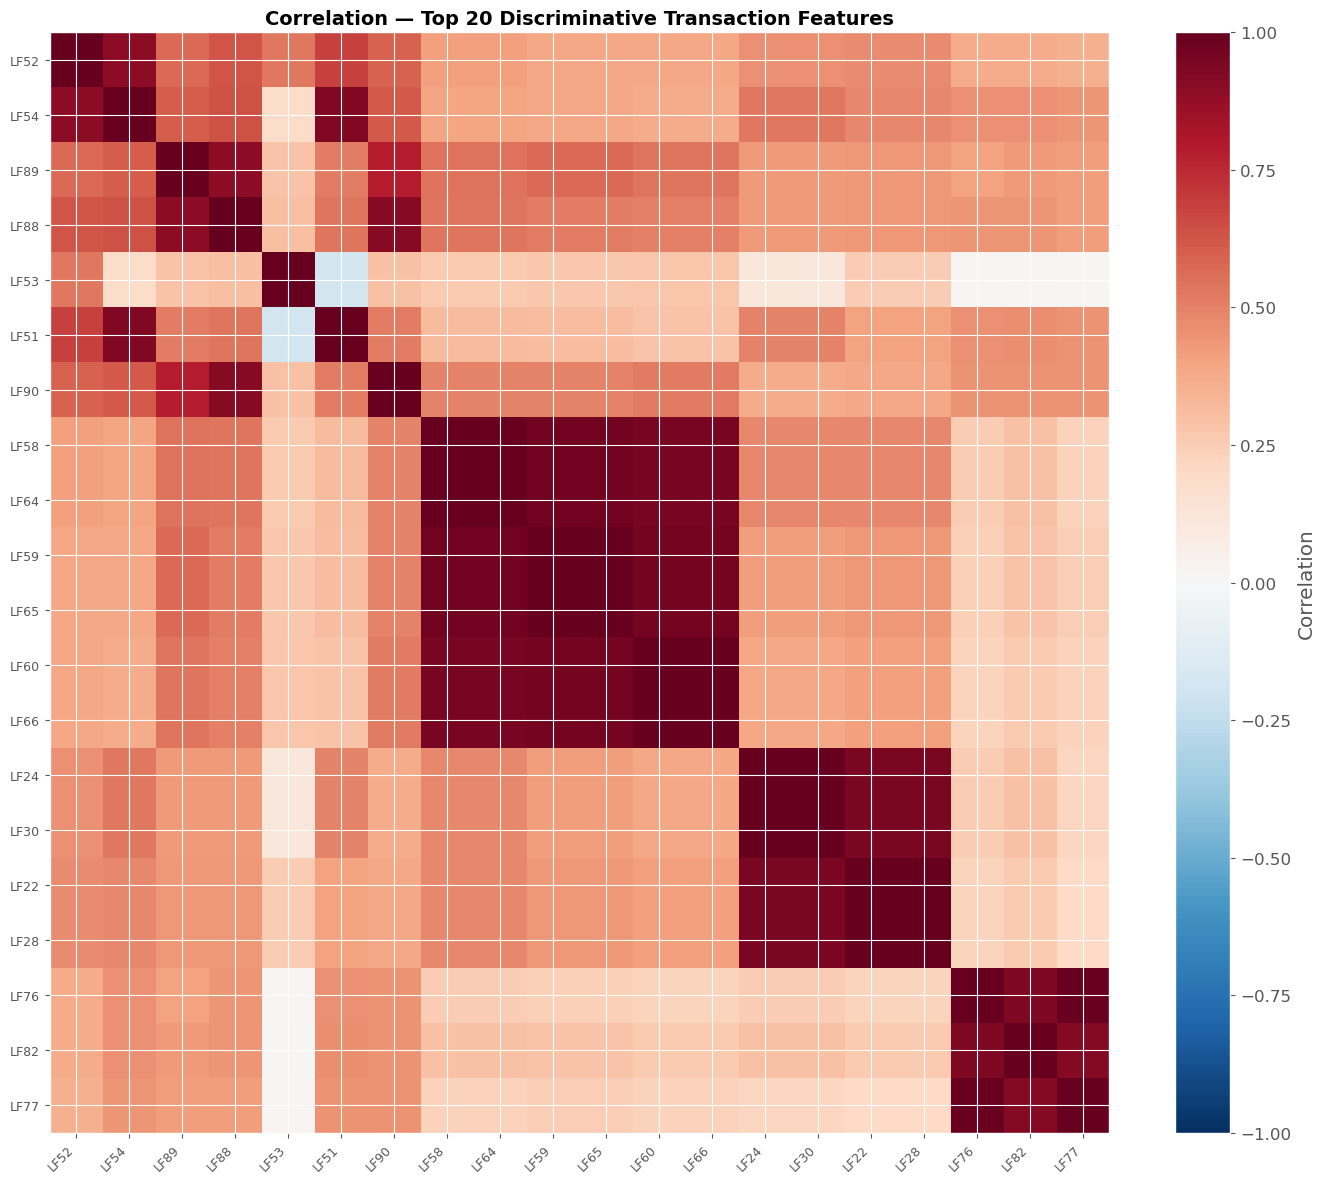

Saved: tx_feature_correlation.png


In [31]:
# ── Feature Correlation Heatmap ──
top_20_feats = [f[0] for f in feat_diffs[:20]]
corr = labeled_tx[top_20_feats].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(top_20_feats)))
ax.set_yticks(range(len(top_20_feats)))
ax.set_xticklabels([f.replace('local_feat_', 'LF') for f in top_20_feats], rotation=45, ha='right', fontsize=9)
ax.set_yticklabels([f.replace('local_feat_', 'LF') for f in top_20_feats], fontsize=9)
plt.colorbar(im, ax=ax, label='Correlation')
ax.set_title('Correlation — Top 20 Discriminative Transaction Features', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'tx_feature_correlation.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: tx_feature_correlation.png")

## 10. Transaction feature importance
Estimate which transaction features seem most useful for separating the two classes.


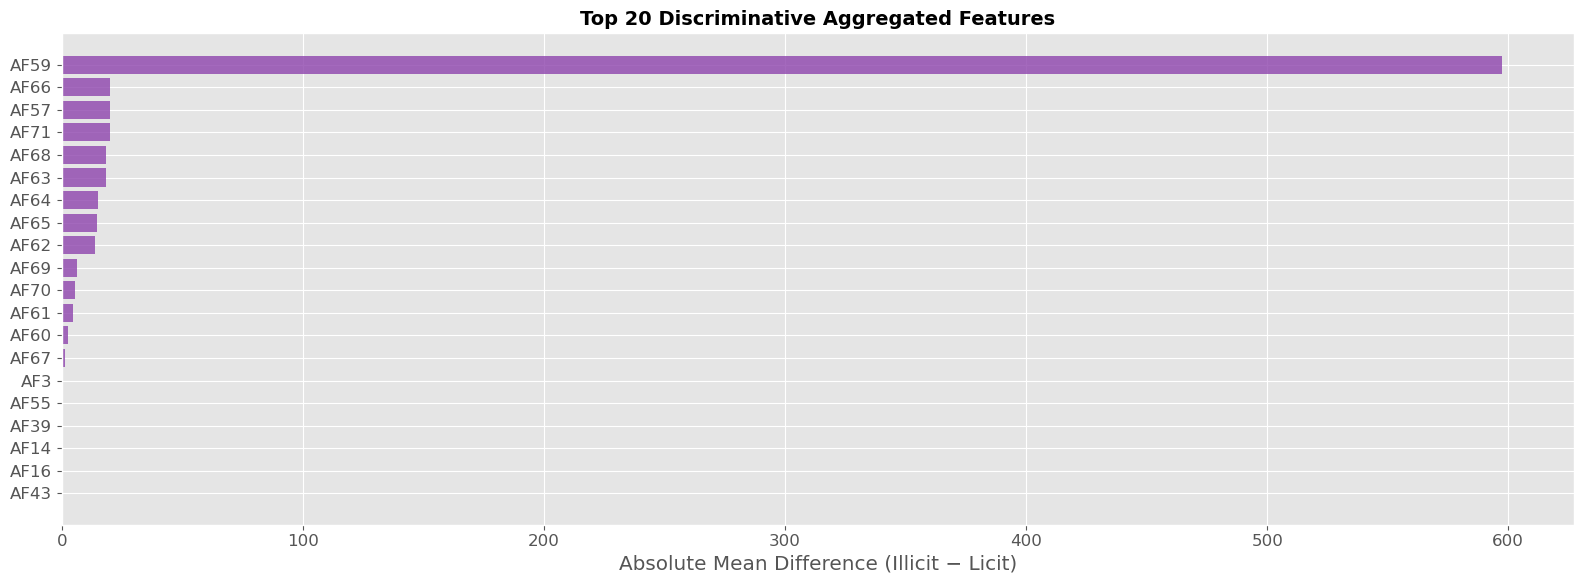

Saved: tx_agg_feature_importance.png


In [32]:
# ── Aggregated Feature Importance ──
agg_feat_cols = [c for c in txs_df.columns if c.startswith('agg_feat_')]
agg_diffs = []
for col in agg_feat_cols:
    diff = abs(labeled_tx[labeled_tx['class'] == 'illicit'][col].mean() -
               labeled_tx[labeled_tx['class'] == 'licit'][col].mean())
    agg_diffs.append((col, diff))
agg_diffs.sort(key=lambda x: x[1], reverse=True)

fig, ax = plt.subplots(figsize=(16, 6))
top_agg = agg_diffs[:20]
ax.barh([f[0].replace('agg_feat_', 'AF') for f in top_agg],
        [f[1] for f in top_agg], color='#8e44ad', alpha=0.8)
ax.set_xlabel('Absolute Mean Difference (Illicit − Licit)')
ax.set_title('Top 20 Discriminative Aggregated Features', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'tx_agg_feature_importance.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: tx_agg_feature_importance.png")

Actor ID column: address
Actor label column: class

Actor label distribution:
label
3          557588
licit      251088
illicit     14266
Name: count, dtype: int64


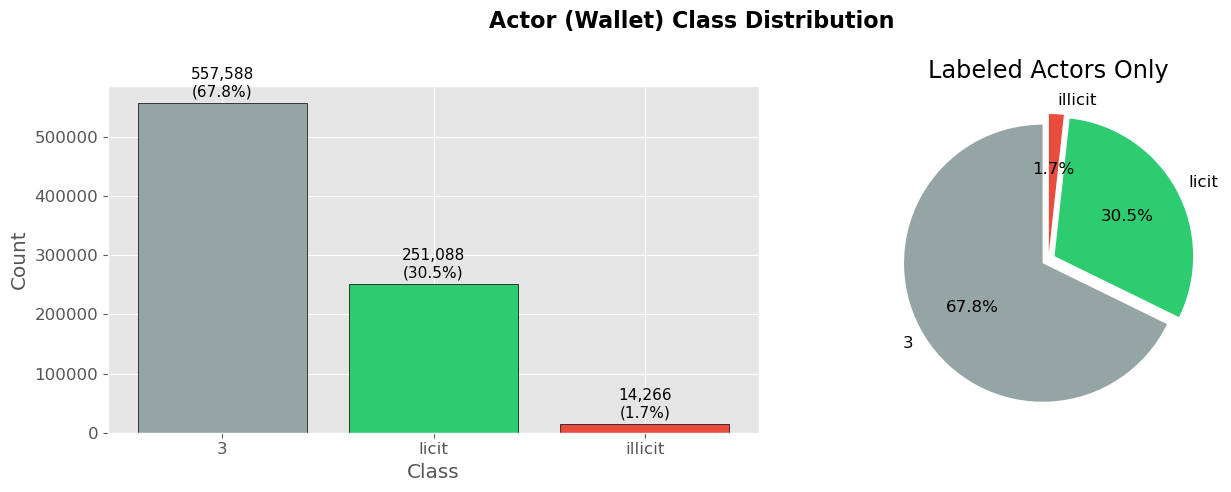

Saved: actor_class_distribution.png


In [33]:
# ══════════════════════════════════════════════════════════
# SECTION 4: ACTOR (WALLET) STATISTICS
# ══════════════════════════════════════════════════════════

# Detect label column
label_col = None
for col in actor_classes_df.columns:
    if 'class' in col.lower() or 'label' in col.lower():
        label_col = col
        break
if label_col is None:
    label_col = actor_classes_df.columns[-1]

actor_id_col = actor_classes_df.columns[0]
print(f"Actor ID column: {actor_id_col}")
print(f"Actor label column: {label_col}")

# Map labels
actor_labels = actor_classes_df.copy()
actor_labels['label'] = actor_labels[label_col].astype(str)
label_map = {'1': 'illicit', '2': 'licit', 'unknown': 'unknown'}
actor_labels['label'] = actor_labels['label'].map(lambda x: label_map.get(x, x))

print(f"\nActor label distribution:")
print(actor_labels['label'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Actor (Wallet) Class Distribution', fontsize=16, fontweight='bold')

actor_counts = actor_labels['label'].value_counts()
a_colors = {'illicit': '#e74c3c', 'licit': '#2ecc71', 'unknown': '#95a5a6'}
bar_colors = [a_colors.get(c, '#95a5a6') for c in actor_counts.index]

axes[0].bar(actor_counts.index, actor_counts.values, color=bar_colors, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, (cls, cnt) in enumerate(actor_counts.items()):
    axes[0].text(i, cnt + max(actor_counts.values) * 0.02,
                 f'{cnt:,}\n({cnt/len(actor_labels)*100:.1f}%)', ha='center', fontsize=11)

# Pie (labeled only)
labeled_actors = actor_labels[actor_labels['label'] != 'unknown']
if len(labeled_actors) > 0:
    la_counts = labeled_actors['label'].value_counts()
    axes[1].pie(la_counts, labels=la_counts.index,
                colors=[a_colors.get(c, '#95a5a6') for c in la_counts.index],
                autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12},
                explode=[0.05] * len(la_counts))
    axes[1].set_title('Labeled Actors Only')
else:
    axes[1].text(0.5, 0.5, 'No labeled actors', ha='center', va='center', fontsize=14)
    axes[1].set_title('Labeled Actors Only')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'actor_class_distribution.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: actor_class_distribution.png")

## 11. Actor interaction structure
Switch from transactions to the actor/wallet layer and inspect how wallets connect to one another.


In [34]:
# ══════════════════════════════════════════════════════════
# SECTION 5: ACTOR GRAPH — INTERACTION NETWORK
# ══════════════════════════════════════════════════════════

print("Building actor interaction graph...")
actor_edge_cols = actor_edgelist_df.columns.tolist()
actorG = nx.from_pandas_edgelist(actor_edgelist_df, source=actor_edge_cols[0],
                                  target=actor_edge_cols[1], create_using=nx.DiGraph())

print(f"Actor graph nodes: {actorG.number_of_nodes():,}")
print(f"Actor graph edges: {actorG.number_of_edges():,}")
print(f"Avg in-degree:  {np.mean([d for _, d in actorG.in_degree()]):.2f}")
print(f"Avg out-degree: {np.mean([d for _, d in actorG.out_degree()]):.2f}")
print(f"Density: {nx.density(actorG):.6f}")

num_wcc = nx.number_weakly_connected_components(actorG)
largest_wcc = max(nx.weakly_connected_components(actorG), key=len)
print(f"Weakly connected components: {num_wcc:,}")
print(f"Largest component: {len(largest_wcc):,} ({len(largest_wcc)/actorG.number_of_nodes()*100:.1f}%)")

Building actor interaction graph...
Actor graph nodes: 822,942
Actor graph edges: 2,784,344
Avg in-degree:  3.38
Avg out-degree: 3.38
Density: 0.000004
Weakly connected components: 2
Largest component: 822,935 (100.0%)


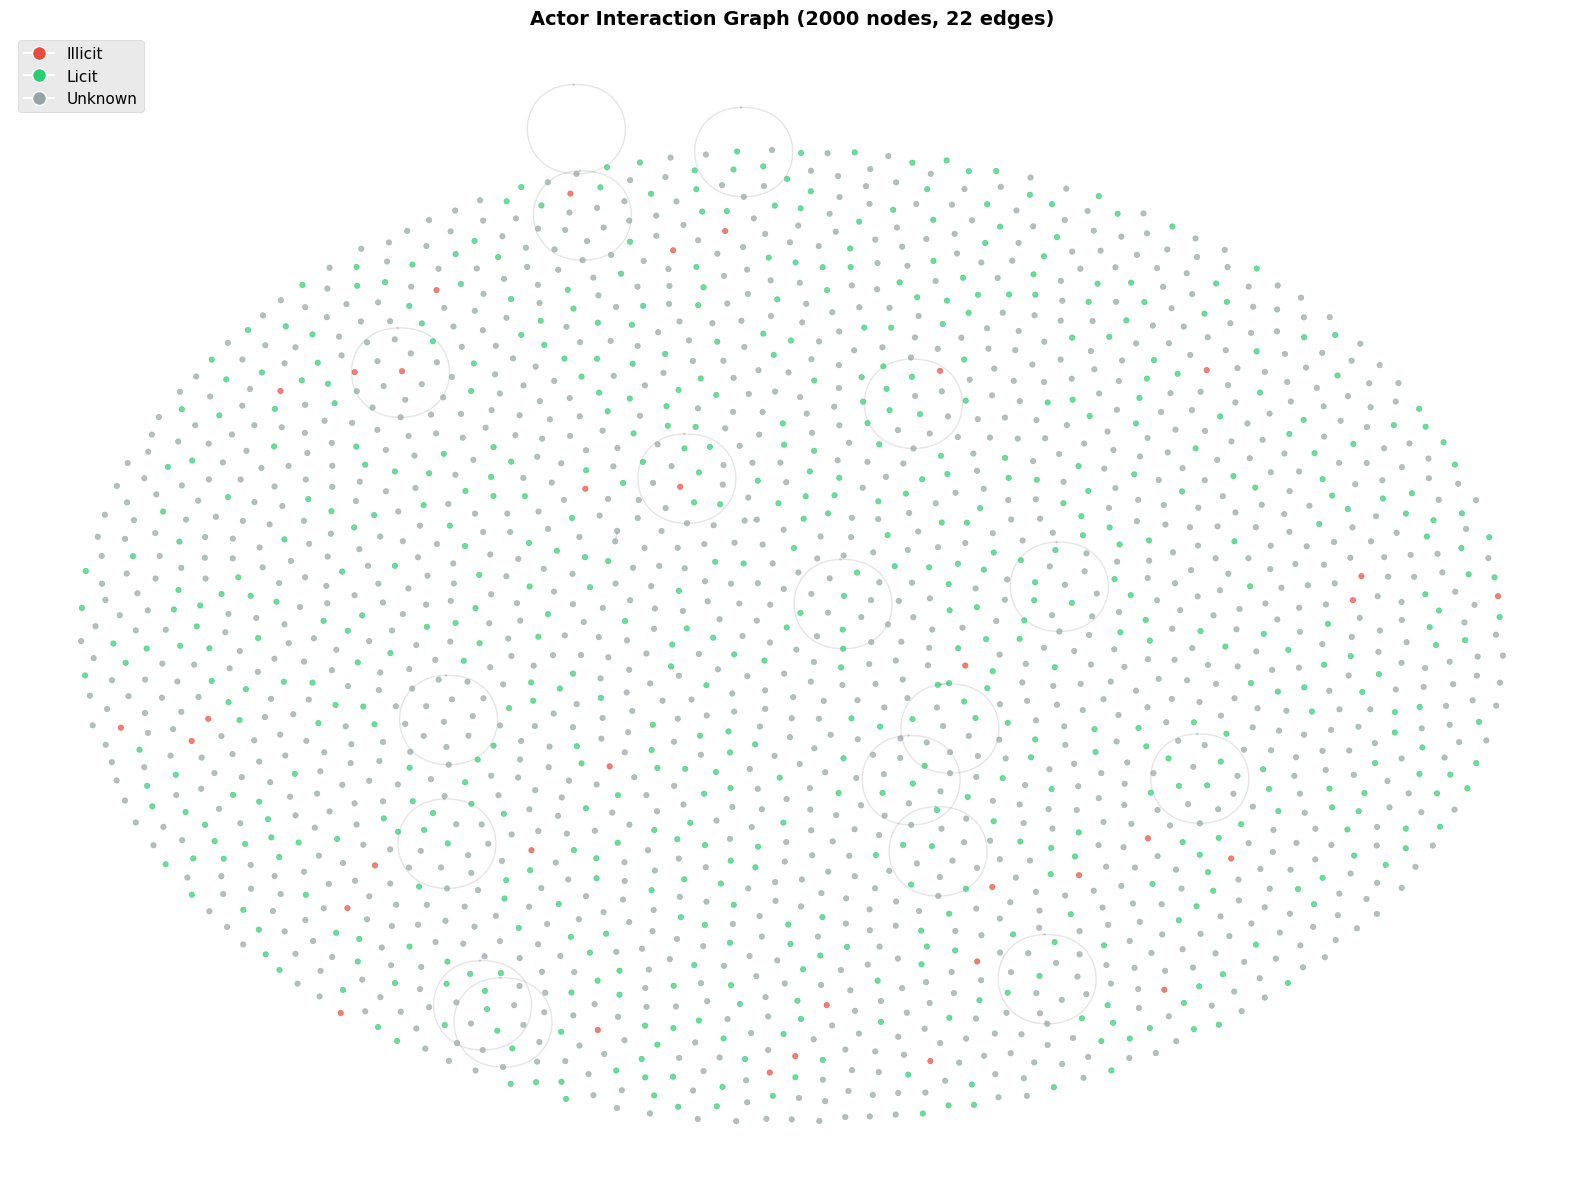

Saved: actor_interaction_sample_graph.png


In [47]:
# ── Actor Interaction Subgraph ──
# Use largest connected component, sample if too large
if len(largest_wcc) > 2000:
    sampled_nodes = list(largest_wcc)[:2000]
else:
    sampled_nodes = list(largest_wcc)

sub_actorG = actorG.subgraph(sampled_nodes).copy()

# Map actor labels
actor_label_map = dict(zip(actor_labels[actor_id_col].astype(str), actor_labels['label']))

actor_node_colors = []
for n in sub_actorG.nodes():
    cls = actor_label_map.get(str(n), 'unknown')
    actor_node_colors.append(a_colors.get(cls, '#95a5a6'))

fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(sub_actorG, seed=42, k=0.3, iterations=30)
nx.draw_networkx_edges(sub_actorG, pos, alpha=0.1, arrows=True, arrowsize=3, ax=ax)
nx.draw_networkx_nodes(sub_actorG, pos, node_color=actor_node_colors, node_size=15, alpha=0.7, ax=ax)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Illicit'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=10, label='Licit'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#95a5a6', markersize=10, label='Unknown'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)
ax.set_title(f'Actor Interaction Graph ({sub_actorG.number_of_nodes()} nodes, {sub_actorG.number_of_edges()} edges)',
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'actor_interaction_graph.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: actor_interaction_sample_graph.png")

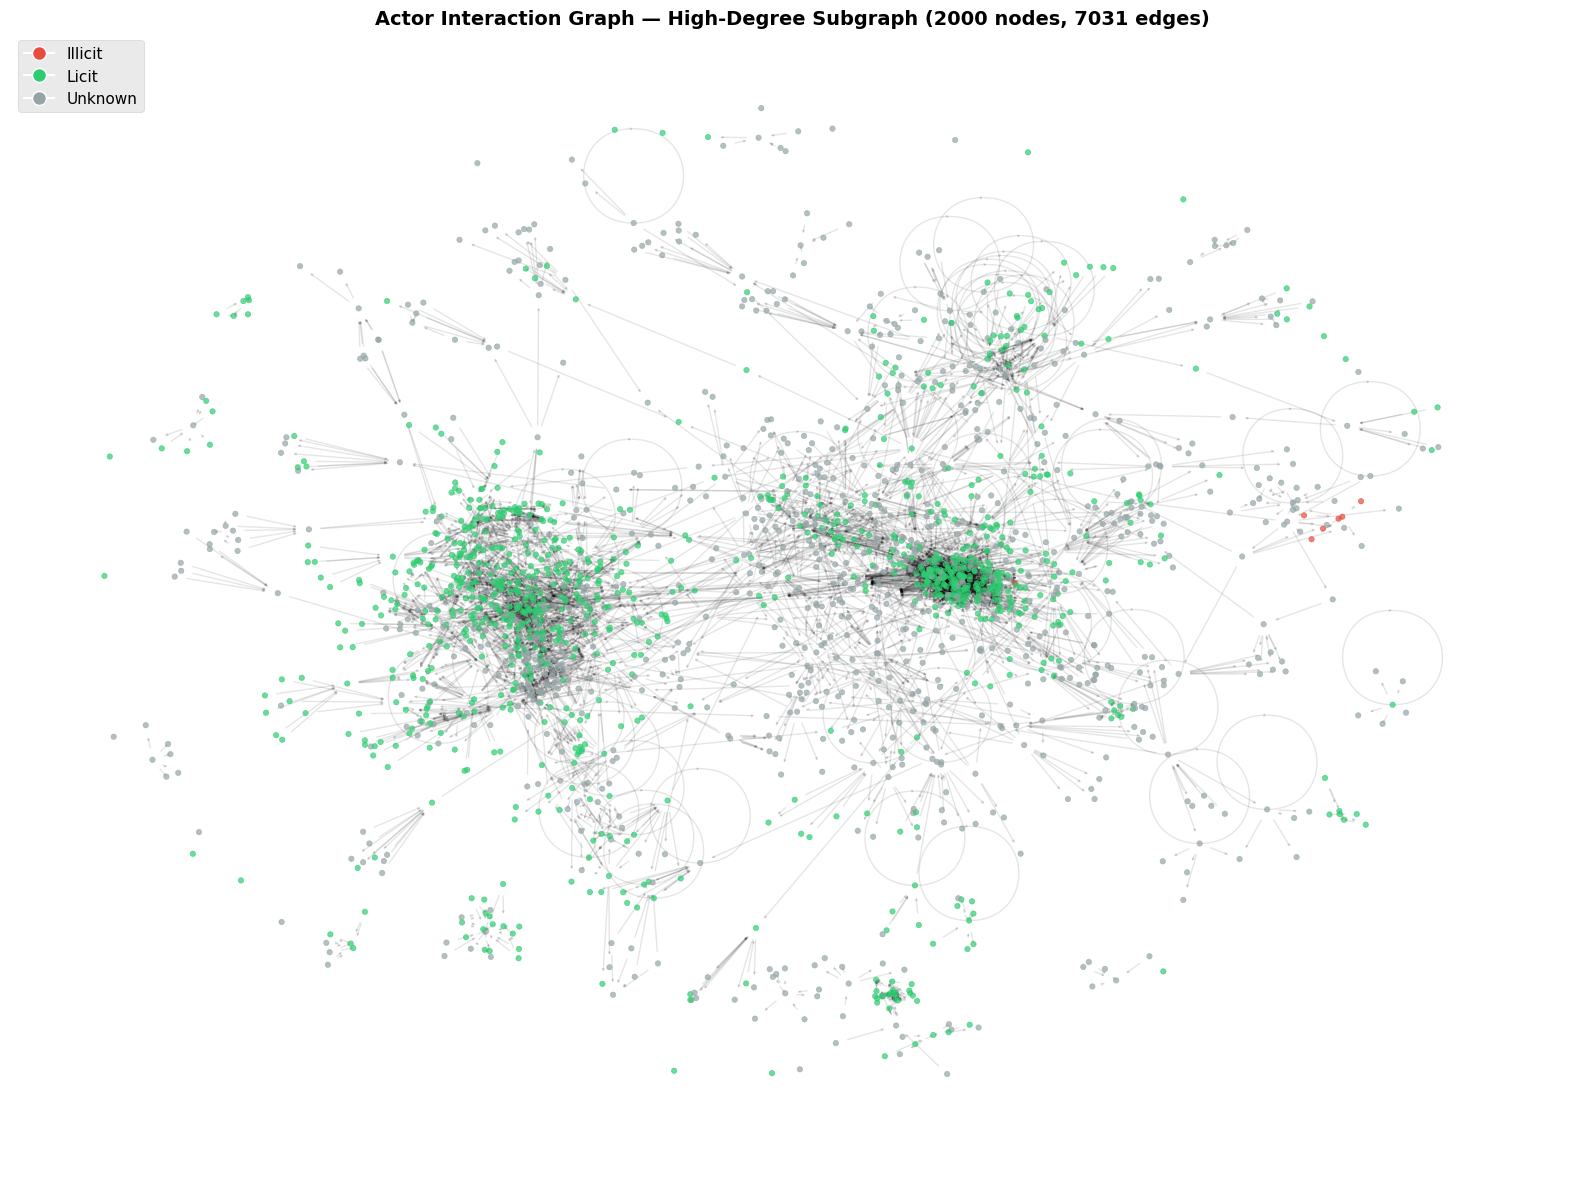

Saved: actor_interaction_graph.png


In [39]:
# ── Actor Interaction Subgraph ──
# Sample nodes with highest degree for a more interesting visualization
top_nodes = sorted(actorG.degree(), key=lambda x: x[1], reverse=True)[:500]
seed_nodes = set(n for n, d in top_nodes)

# Add their neighbors
sample_nodes = set(seed_nodes)
for n in seed_nodes:
    sample_nodes.update(list(actorG.successors(n))[:5])
    sample_nodes.update(list(actorG.predecessors(n))[:5])

# Limit size
sample_nodes = list(sample_nodes)[:2000]
sub_actorG = actorG.subgraph(sample_nodes).copy()

# Map actor labels
actor_node_colors = []
for n in sub_actorG.nodes():
    cls = actor_label_map.get(str(n), 'unknown')
    actor_node_colors.append(a_colors.get(cls, '#95a5a6'))

fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(sub_actorG, seed=42, k=0.3, iterations=30)
nx.draw_networkx_edges(sub_actorG, pos, alpha=0.1, arrows=True, arrowsize=3, ax=ax)
nx.draw_networkx_nodes(sub_actorG, pos, node_color=actor_node_colors, node_size=15, alpha=0.7, ax=ax)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Illicit'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=10, label='Licit'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#95a5a6', markersize=10, label='Unknown'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)
ax.set_title(f'Actor Interaction Graph — High-Degree Subgraph ({sub_actorG.number_of_nodes()} nodes, {sub_actorG.number_of_edges()} edges)',
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'actor_interaction_graph.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: actor_interaction_graph.png")

## 12. Actor degree patterns
Compare wallet degree distributions and see whether illicit and licit actors differ structurally.


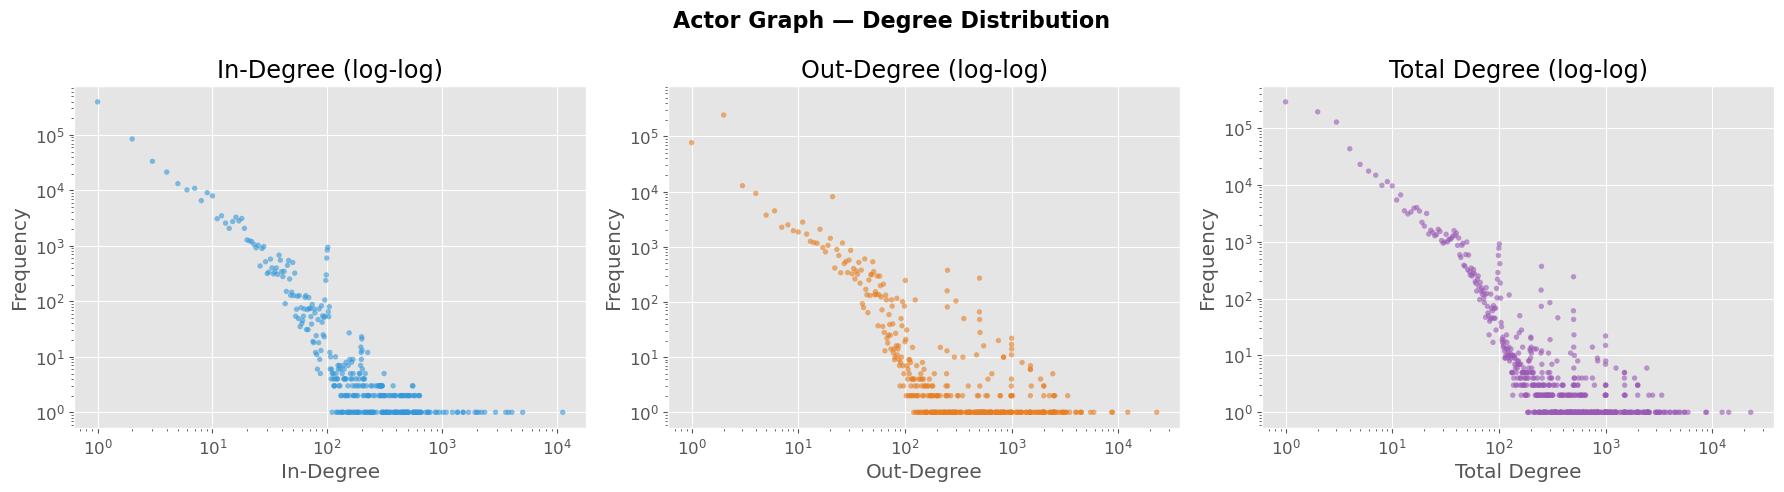

Saved: actor_degree_distribution.png


In [36]:
# ══════════════════════════════════════════════════════════
# SECTION 6: ACTOR DEGREE DISTRIBUTION
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Actor Graph — Degree Distribution', fontsize=16, fontweight='bold')

a_in = [d for _, d in actorG.in_degree()]
a_out = [d for _, d in actorG.out_degree()]
a_total = [d for _, d in actorG.degree()]

for ax, degrees, title, color in zip(
    axes, [a_in, a_out, a_total],
    ['In-Degree', 'Out-Degree', 'Total Degree'],
    ['#3498db', '#e67e22', '#9b59b6']
):
    deg_counts = Counter(degrees)
    vals = sorted(deg_counts.keys())
    freqs = [deg_counts[d] for d in vals]
    ax.scatter(vals, freqs, c=color, alpha=0.6, s=15, edgecolors='none')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'{title} (log-log)')
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'actor_degree_distribution.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: actor_degree_distribution.png")

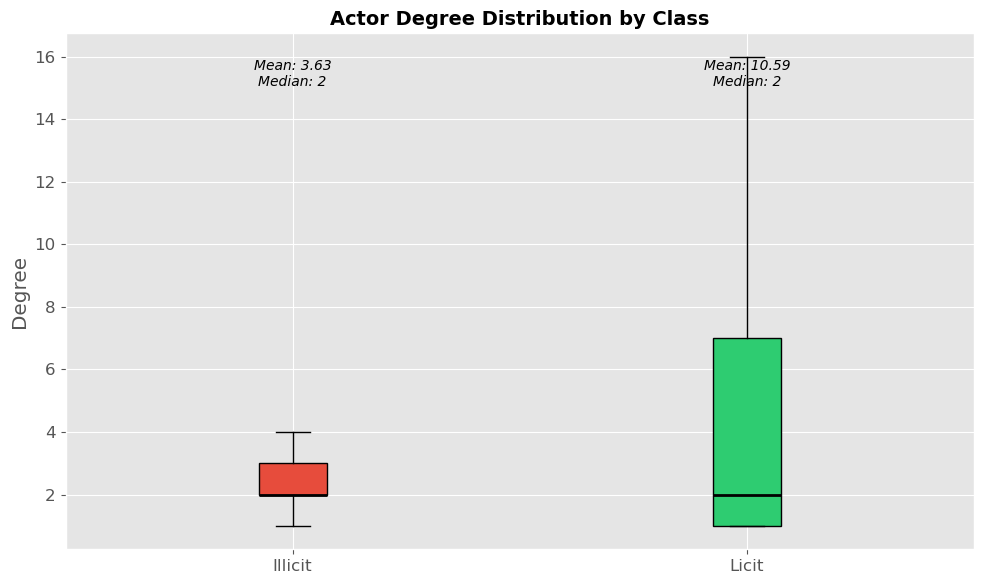

Saved: actor_degree_by_class.png


In [37]:
# ── Actor Degree by Class ──
actor_deg_dict = dict(actorG.degree())

actor_deg_by_class = {'illicit': [], 'licit': []}
for node, deg in actor_deg_dict.items():
    cls = actor_label_map.get(str(node), 'unknown')
    if cls in actor_deg_by_class:
        actor_deg_by_class[cls].append(deg)

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(
    [actor_deg_by_class['illicit'], actor_deg_by_class['licit']],
    labels=['Illicit', 'Licit'], patch_artist=True, showfliers=False,
    medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][1].set_facecolor('#2ecc71')

ax.set_title('Actor Degree Distribution by Class', fontsize=14, fontweight='bold')
ax.set_ylabel('Degree')

for i, cls in enumerate(['illicit', 'licit']):
    if len(actor_deg_by_class[cls]) > 0:
        mean_val = np.mean(actor_deg_by_class[cls])
        median_val = np.median(actor_deg_by_class[cls])
        ax.text(i + 1, ax.get_ylim()[1] * 0.9,
                f'Mean: {mean_val:.2f}\nMedian: {median_val:.0f}',
                ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'actor_degree_by_class.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: actor_degree_by_class.png")

Address-TX columns: ['input_address', 'txId']
TX-Address columns: ['txId', 'output_address']
Address → TX edges: 477,117
TX → Address edges: 837,124

Bipartite graph total nodes: 1,025,746
  Address nodes: 822,942
  Transaction nodes: 202,804
  Total edges: 1,314,241


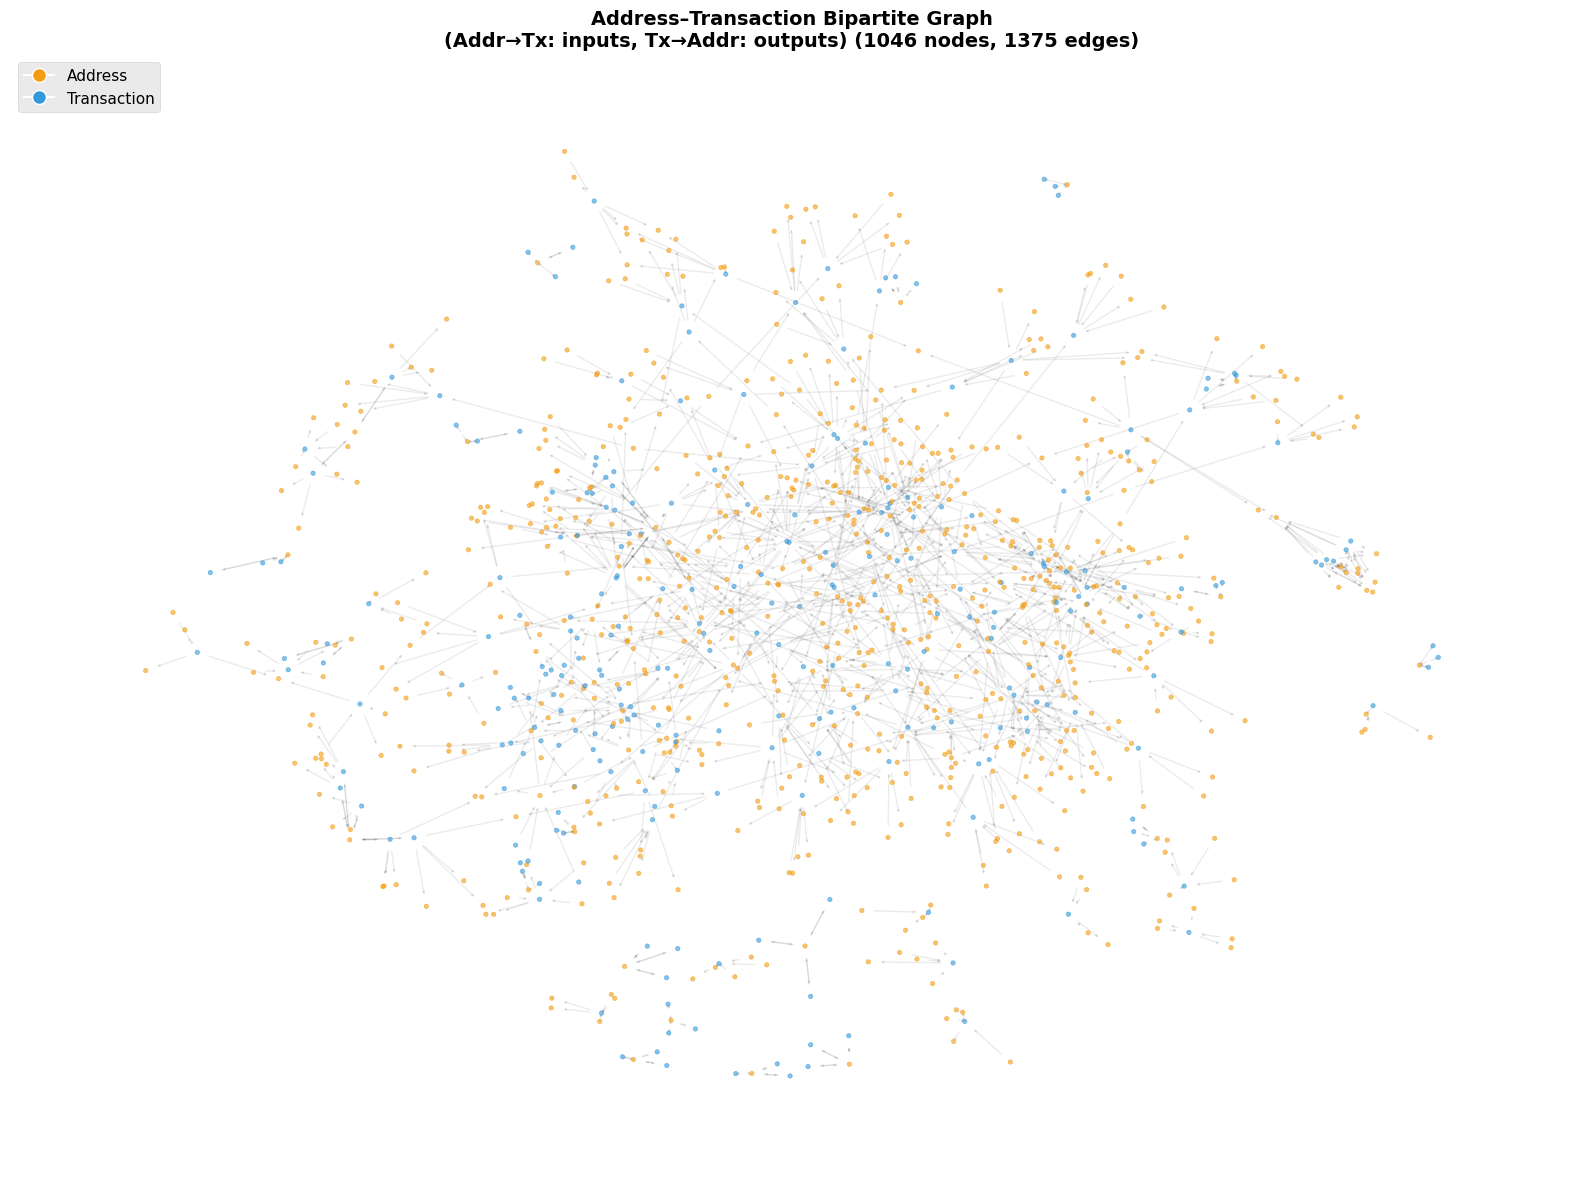

Saved: address_transaction_graph.png


In [41]:
# ══════════════════════════════════════════════════════════
# SECTION 7: ADDRESS-TRANSACTION GRAPH
# ══════════════════════════════════════════════════════════

print("Address-TX columns:", addr_tx_df.columns.tolist())
print("TX-Address columns:", tx_addr_df.columns.tolist())
print(f"Address → TX edges: {len(addr_tx_df):,}")
print(f"TX → Address edges: {len(tx_addr_df):,}")

# Build directed bipartite graph
biG = nx.DiGraph()

# Add Address → Transaction edges (inputs)
addr_tx_cols = addr_tx_df.columns.tolist()
for _, row in addr_tx_df.iterrows():
    addr = f"addr_{row[addr_tx_cols[0]]}"
    tx = f"tx_{row[addr_tx_cols[1]]}"
    biG.add_node(addr, bipartite='address')
    biG.add_node(tx, bipartite='transaction')
    biG.add_edge(addr, tx)

# Add Transaction → Address edges (outputs)
tx_addr_cols = tx_addr_df.columns.tolist()
for _, row in tx_addr_df.iterrows():
    tx = f"tx_{row[tx_addr_cols[0]]}"
    addr = f"addr_{row[tx_addr_cols[1]]}"
    biG.add_node(tx, bipartite='transaction')
    biG.add_node(addr, bipartite='address')
    biG.add_edge(tx, addr)

addr_nodes = [n for n, d in biG.nodes(data=True) if d.get('bipartite') == 'address']
tx_nodes = [n for n, d in biG.nodes(data=True) if d.get('bipartite') == 'transaction']

print(f"\nBipartite graph total nodes: {biG.number_of_nodes():,}")
print(f"  Address nodes: {len(addr_nodes):,}")
print(f"  Transaction nodes: {len(tx_nodes):,}")
print(f"  Total edges: {biG.number_of_edges():,}")

# ── Visualize a sample subgraph ──
# Sample high-degree nodes for a meaningful visualization
top_bi_nodes = sorted(biG.degree(), key=lambda x: x[1], reverse=True)[:200]
seed_bi = set(n for n, d in top_bi_nodes)

sample_bi_nodes = set(seed_bi)
for n in seed_bi:
    sample_bi_nodes.update(list(biG.successors(n))[:3])
    sample_bi_nodes.update(list(biG.predecessors(n))[:3])

sample_bi_nodes = list(sample_bi_nodes)[:2000]
sub_biG = biG.subgraph(sample_bi_nodes).copy()

# Color by type
bi_colors = []
for n in sub_biG.nodes():
    if n.startswith('addr_'):
        bi_colors.append('#f39c12')
    else:
        bi_colors.append('#3498db')

fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(sub_biG, seed=42, k=0.4, iterations=20)
nx.draw_networkx_edges(sub_biG, pos, alpha=0.08, arrows=True, arrowsize=3, ax=ax)
nx.draw_networkx_nodes(sub_biG, pos, node_color=bi_colors, node_size=10, alpha=0.6, ax=ax)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#f39c12', markersize=10, label='Address'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=10, label='Transaction'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)
ax.set_title(f'Address–Transaction Bipartite Graph\n'
             f'(Addr→Tx: inputs, Tx→Addr: outputs) '
             f'({sub_biG.number_of_nodes()} nodes, {sub_biG.number_of_edges()} edges)',
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'address_transaction_graph.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: address_transaction_graph.png")

## 13. Actor feature correlations
Check whether wallet-level features show strong redundancy or class-dependent structure.


Labeled actors for feature analysis: 367472


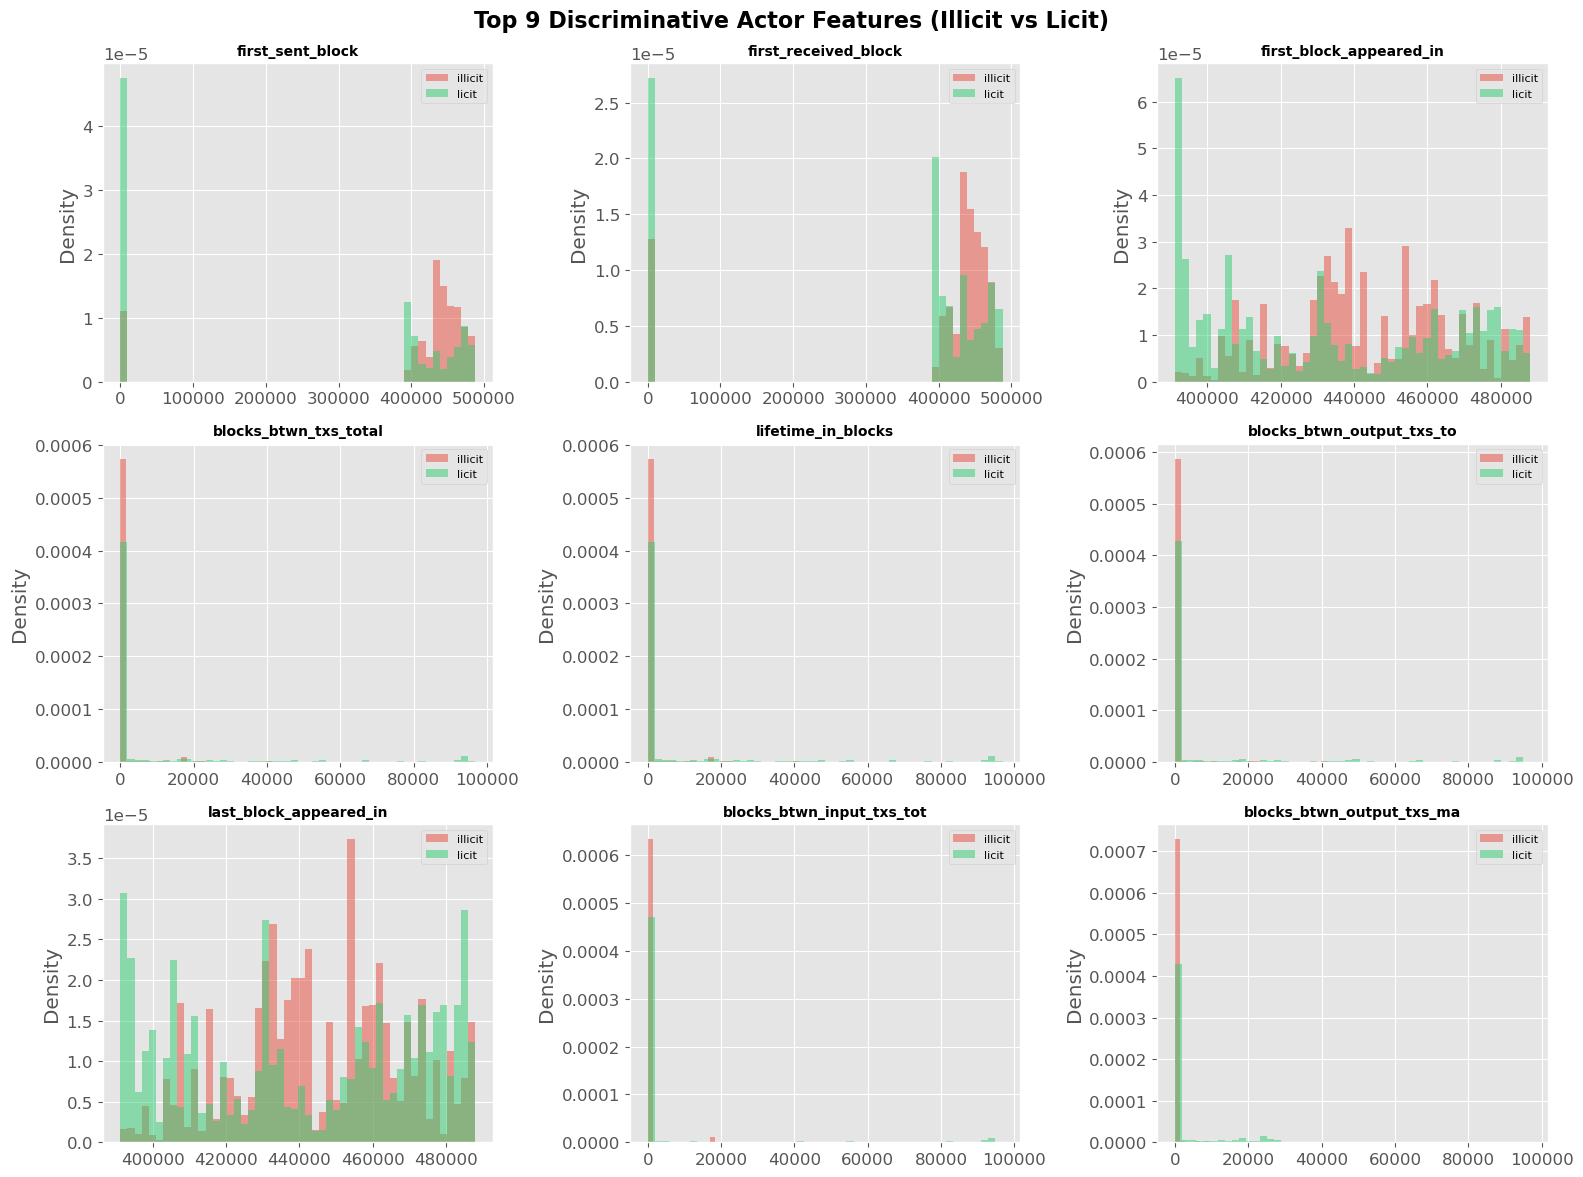

Saved: actor_feature_distributions.png


In [43]:
# ══════════════════════════════════════════════════════════
# SECTION 8: ACTOR FEATURE ANALYSIS
# ══════════════════════════════════════════════════════════

# Merge actor features with labels
actor_feat_id_col = actor_features_df.columns[0]
actor_feat_cols = actor_features_df.columns[1:].tolist()

actors_merged = actor_features_df.copy()
actors_merged['label'] = actors_merged[actor_feat_id_col].astype(str).map(actor_label_map)
actors_merged['label'] = actors_merged['label'].fillna('unknown')

labeled_actors_df = actors_merged[actors_merged['label'].isin(['illicit', 'licit'])]
print(f"Labeled actors for feature analysis: {len(labeled_actors_df)}")

# Find numeric feature columns
numeric_cols = actors_merged.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != actor_feat_id_col]

if len(labeled_actors_df) > 0 and len(numeric_cols) > 0:
    # Top 9 discriminative actor features
    actor_feat_diffs = []
    for col in numeric_cols:
        diff = abs(labeled_actors_df[labeled_actors_df['label'] == 'illicit'][col].mean() -
                   labeled_actors_df[labeled_actors_df['label'] == 'licit'][col].mean())
        actor_feat_diffs.append((col, diff))
    actor_feat_diffs.sort(key=lambda x: x[1], reverse=True)
    top_actor_feats = [f[0] for f in actor_feat_diffs[:9]]

    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    fig.suptitle('Top 9 Discriminative Actor Features (Illicit vs Licit)', fontsize=16, fontweight='bold')

    for ax, feat in zip(axes.flat, top_actor_feats):
        for cls, color in [('illicit', '#e74c3c'), ('licit', '#2ecc71')]:
            data = labeled_actors_df[labeled_actors_df['label'] == cls][feat].dropna()
            ax.hist(data, bins=50, alpha=0.5, color=color, label=cls, density=True)
        ax.set_title(feat[:25], fontsize=10, fontweight='bold')
        ax.legend(fontsize=8)
        ax.set_ylabel('Density')

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'actor_feature_distributions.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print("Saved: actor_feature_distributions.png")
else:
    print("[WARN] Not enough labeled actors or numeric features for analysis.")

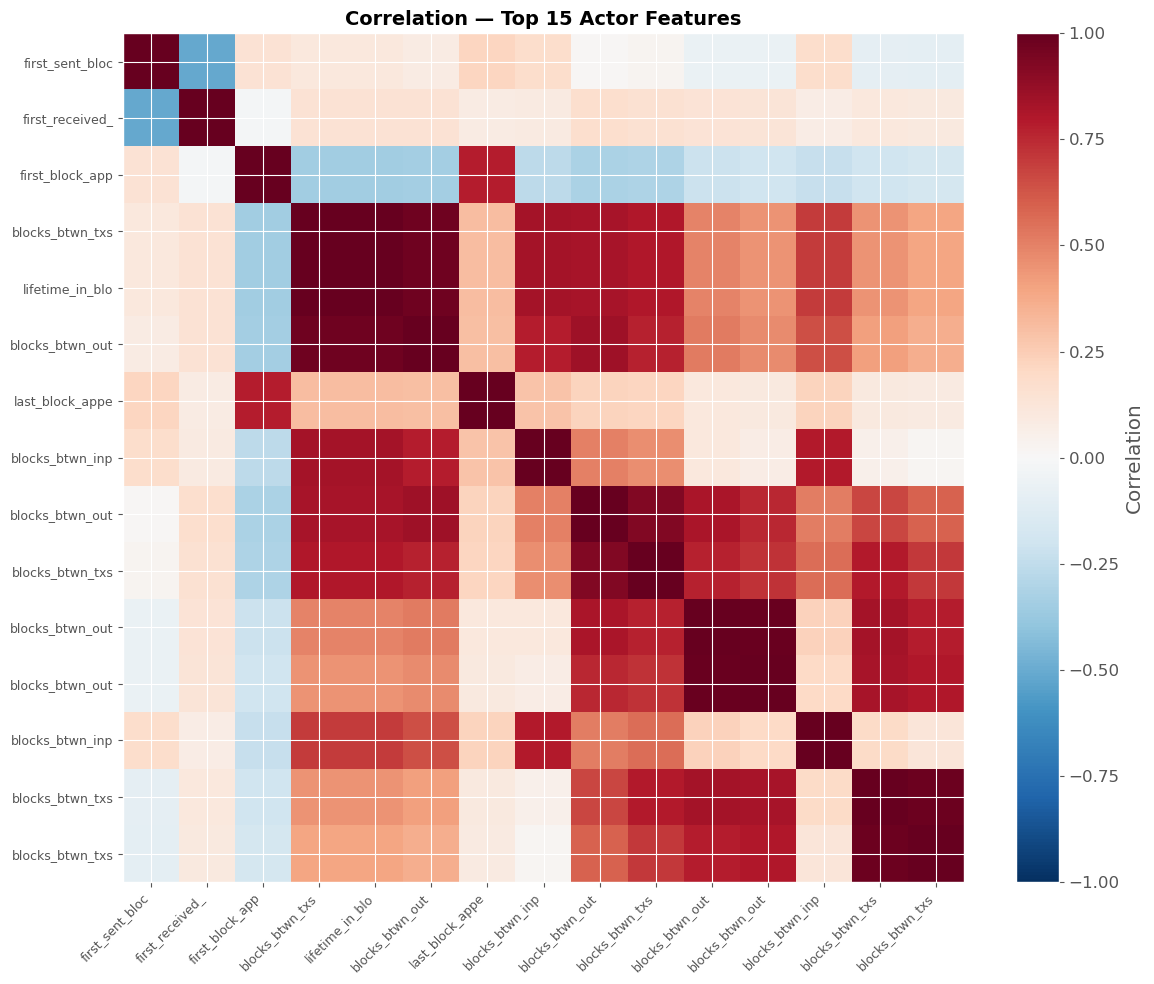

Saved: actor_feature_correlation.png


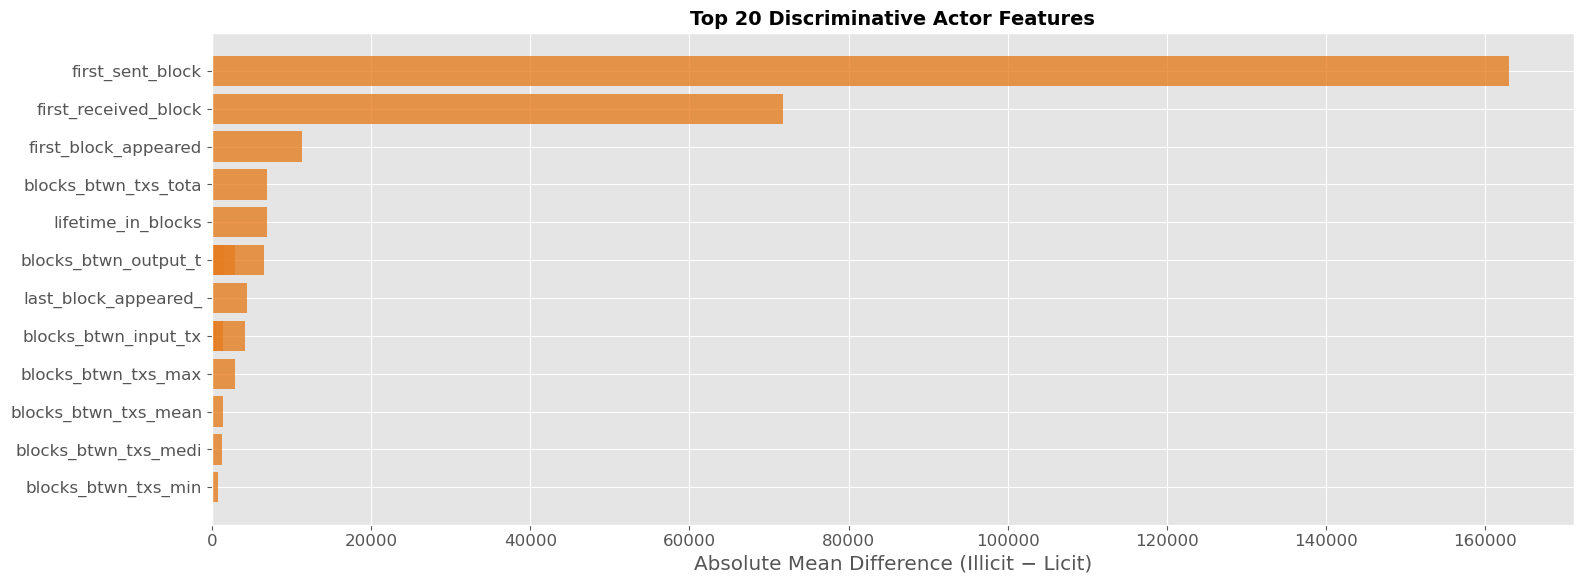

Saved: actor_feature_importance.png


In [44]:
# ── Actor Feature Correlation Heatmap ──
if len(actor_feat_diffs) >= 15:
    top_actor_20 = [f[0] for f in actor_feat_diffs[:15]]
    corr_actor = labeled_actors_df[top_actor_20].corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr_actor.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(top_actor_20)))
    ax.set_yticks(range(len(top_actor_20)))
    ax.set_xticklabels([c[:15] for c in top_actor_20], rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels([c[:15] for c in top_actor_20], fontsize=9)
    plt.colorbar(im, ax=ax, label='Correlation')
    ax.set_title('Correlation — Top 15 Actor Features', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'actor_feature_correlation.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print("Saved: actor_feature_correlation.png")

# ── Actor Feature Importance Bar Chart ──
fig, ax = plt.subplots(figsize=(16, 6))
top_n = min(20, len(actor_feat_diffs))
top_af = actor_feat_diffs[:top_n]
ax.barh([f[0][:20] for f in top_af], [f[1] for f in top_af], color='#e67e22', alpha=0.8)
ax.set_xlabel('Absolute Mean Difference (Illicit − Licit)')
ax.set_title(f'Top {top_n} Discriminative Actor Features', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'actor_feature_importance.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: actor_feature_importance.png")

## 14. Final observations
Wrap up with any additional diagnostics or cross-checks that help interpret the heterogeneous graph.


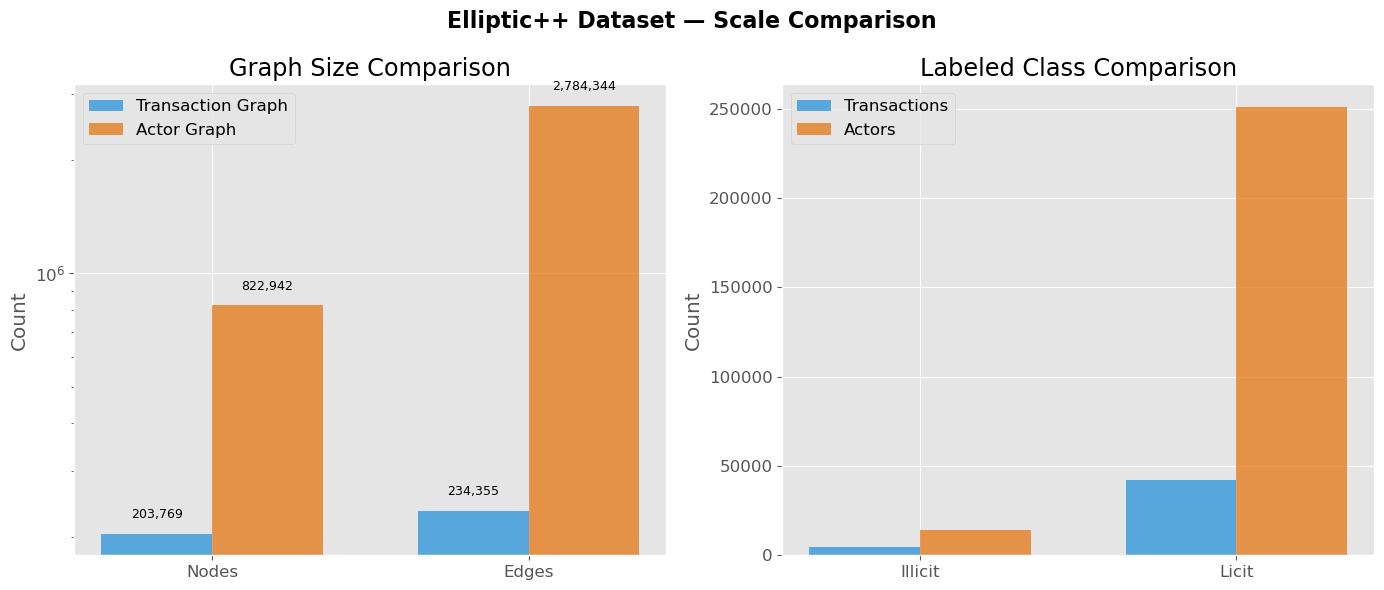

Saved: dataset_comparison.png


In [45]:
# ══════════════════════════════════════════════════════════
# SECTION 9: DATASET COMPARISON — TRANSACTIONS vs ACTORS
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Elliptic++ Dataset — Scale Comparison', fontsize=16, fontweight='bold')

# Node/Edge comparison
categories = ['Nodes', 'Edges']
tx_vals = [txG.number_of_nodes(), txG.number_of_edges()]
actor_vals = [actorG.number_of_nodes(), actorG.number_of_edges()]

x = np.arange(len(categories))
w = 0.35
axes[0].bar(x - w/2, tx_vals, w, label='Transaction Graph', color='#3498db', alpha=0.8)
axes[0].bar(x + w/2, actor_vals, w, label='Actor Graph', color='#e67e22', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].set_ylabel('Count')
axes[0].set_title('Graph Size Comparison')
axes[0].legend()
axes[0].set_yscale('log')
for i in range(len(categories)):
    axes[0].text(i - w/2, tx_vals[i] * 1.1, f'{tx_vals[i]:,}', ha='center', fontsize=9)
    axes[0].text(i + w/2, actor_vals[i] * 1.1, f'{actor_vals[i]:,}', ha='center', fontsize=9)

# Class distribution comparison
tx_illicit = len(txs_df[txs_df['class'] == 'illicit'])
tx_licit = len(txs_df[txs_df['class'] == 'licit'])
a_illicit = len(actor_labels[actor_labels['label'] == 'illicit'])
a_licit = len(actor_labels[actor_labels['label'] == 'licit'])

labels_comp = ['Illicit', 'Licit']
tx_labeled = [tx_illicit, tx_licit]
a_labeled = [a_illicit, a_licit]

x2 = np.arange(len(labels_comp))
axes[1].bar(x2 - w/2, tx_labeled, w, label='Transactions', color='#3498db', alpha=0.8)
axes[1].bar(x2 + w/2, a_labeled, w, label='Actors', color='#e67e22', alpha=0.8)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(labels_comp)
axes[1].set_ylabel('Count')
axes[1].set_title('Labeled Class Comparison')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dataset_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: dataset_comparison.png")

In [46]:
# ══════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════

print("=" * 65)
print("ELLIPTIC++ DATASET — EDA SUMMARY")
print("=" * 65)
print(f"\n{'TRANSACTIONS':─<40}")
print(f"  Total transactions:   {len(txs_df):,}")
print(f"  Illicit:              {len(txs_df[txs_df['class']=='illicit']):,}")
print(f"  Licit:                {len(txs_df[txs_df['class']=='licit']):,}")
print(f"  Unknown:              {len(txs_df[txs_df['class']=='unknown']):,}")
print(f"  TX graph nodes:       {txG.number_of_nodes():,}")
print(f"  TX graph edges:       {txG.number_of_edges():,}")
print(f"  Time steps:           {int(txs_df['time_step'].nunique())}")
print(f"\n{'ACTORS (WALLETS)':─<40}")
print(f"  Total actors:         {len(actor_labels):,}")
print(f"  Illicit:              {len(actor_labels[actor_labels['label']=='illicit']):,}")
print(f"  Licit:                {len(actor_labels[actor_labels['label']=='licit']):,}")
print(f"  Unknown:              {len(actor_labels[actor_labels['label']=='unknown']):,}")
print(f"  Actor graph nodes:    {actorG.number_of_nodes():,}")
print(f"  Actor graph edges:    {actorG.number_of_edges():,}")
print(f"\n{'ADDRESSES':─<40}")
print(f"  Unique addresses:     {addr_tx_df[addr_tx_df.columns[0]].nunique():,}")
print(f"  Address-TX links:     {len(addr_tx_df):,}")
print("=" * 65)

print(f"\nAll figures saved to: {os.path.abspath(FIG_DIR)}")
saved_figs = sorted([f for f in os.listdir(FIG_DIR) if f.endswith('.png')])
for f in saved_figs:
    print(f"  ✓ {f}")

ELLIPTIC++ DATASET — EDA SUMMARY

TRANSACTIONS────────────────────────────
  Total transactions:   203,769
  Illicit:              4,545
  Licit:                42,019
  Unknown:              157,205
  TX graph nodes:       203,769
  TX graph edges:       234,355
  Time steps:           49

ACTORS (WALLETS)────────────────────────
  Total actors:         822,942
  Illicit:              14,266
  Licit:                251,088
  Unknown:              0
  Actor graph nodes:    822,942
  Actor graph edges:    2,784,344

ADDRESSES───────────────────────────────
  Unique addresses:     400,212
  Address-TX links:     477,117

All figures saved to: /Users/kuijun/Desktop/spring-2026-spec-proj/outputs/figures/elliptic_plus
  ✓ actor_class_distribution.png
  ✓ actor_degree_by_class.png
  ✓ actor_degree_distribution.png
  ✓ actor_feature_correlation.png
  ✓ actor_feature_distributions.png
  ✓ actor_feature_importance.png
  ✓ actor_interaction_graph.png
  ✓ address_transaction_graph.png
  ✓ dataset